# Limpieza y obtención de data

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab9)
- [Data](https://www.ine.gob.gt/bases-de-datos/accidentes-de-transito/)

## Librerías

In [1]:
import pandas as pd
import pyreadstat
import sys
import os
import re
import glob
import web_scrapping
import subprocess
import unicodedata
import unidecode
import shutil
import matplotlib.pyplot as plt
from contextlib import redirect_stdout
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window

## Constantes

In [2]:
def ensureDir(path):
    """Crea un directorio si no existe y avisa si lo crea o si ya existía."""
    if os.path.exists(path):
        if os.path.isdir(path):
            print(f"El directorio ya existe: {path}")
        else:
            # Existe un archivo en la misma ruta, lo eliminamos
            os.remove(path)
            os.makedirs(path, exist_ok=True)
            print(f"Se eliminó un archivo y se creó el directorio: {path}")
    else:
        os.makedirs(path, exist_ok=True)
        print(f"Directorio creado: {path}")

In [3]:
DATA_BASE = "/opt/app/notebooks/data"
RAW_BASE = os.path.join(DATA_BASE, "raw")
VARIABLE_BASE = os.path.join(DATA_BASE, "variables")
MANIFEST_BASE = os.path.join(RAW_BASE, "manifest.log")
MANIFEST_BASE_VAR = os.path.join(VARIABLE_BASE, "manifest.log")

# Data que almacena los csv
HECHOS_BASE = os.path.join(DATA_BASE, "hechos")
VEHICULOS_BASE = os.path.join(DATA_BASE, "vehiculos")
FL_BASE = os.path.join(DATA_BASE, "fallecidos_lesionados")

# Caché
CACHE_BASE = "/opt/app/notebooks/cache"
CACHE_WEB_SCRAPPING = "cache_web_scrapping.txt"
CACHE_VARIABLES = "cache_variables.txt"
CACHE_CSV_BASE = "cache_csv_base.txt"
CACHE_TRANSFORM_SAV = "cache_transform_sav.txt"
CACHE_SEPARATE = "cache_separate.txt"
CACHE_GENERATED_CSV = "cache_generated_csv.txt"
CACHE_SEPARATE_VAR = "cache_separate_var.txt"

# Preparación archivos unificados
HECHOS_CSV = os.path.join(HECHOS_BASE, "hechos_combinado.csv")
VEHICULOS_CSV = os.path.join(VEHICULOS_BASE, "vehiculos_combinado.csv")
FL_CSV = os.path.join(FL_BASE, "fl_combinado.csv")

HECHOS_COLS = ["num_corre", "anio_ocu", "dia_ocu", "hora_ocu", "g_hora", "g_hora_5", "mes_ocu", "dia_sem_ocu", "depto_ocu", "mupio_ocu", "zona_ocu", "tipo_veh", "marca_veh", "color_veh", "modelo_veh", "g_modelo_veh", "tipo_eve"]
VEHICULOS_COLS = ["mes_ocu", "dia_sem_ocu", "hora_ocu", "depto_ocu", "mupio_ocu", "zona_ocu", "mayor_menor", "tipo_veh", "color_veh", "modelo_veh", "marca_veh", "g_edad", "anio_ocu_file", "tipo_eve", "estado_con", "g_modelo_veh", "sexo_per", "edad_per", "num_corre", "g_hora", "anio_ocu_dataset", "anio_ocu", "edad_grupo"]
FL_COLS = ["mes_ocu", "dia_sem_ocu", "hora_ocu", "g_hora", "depto_ocu", "mupio_ocu", "zona_ocu", "mayor_menor", "tipo_veh", "color_veh", "modelo_veh", "marca_veh", "anio_ocu_file", "tipo_eve", "edad_grupo", "fall_les", "num_corre", "anio_ocu_dataset", "anio_ocu", "sexo_vic", "edad_vic", "int_o_noint"]

# Aseguramos que existan las carpetas
ensureDir(DATA_BASE)
ensureDir(CACHE_BASE)
ensureDir(RAW_BASE)
ensureDir(VARIABLE_BASE)
ensureDir(HECHOS_BASE)
ensureDir(VEHICULOS_BASE)
ensureDir(FL_BASE)

Directorio creado: /opt/app/notebooks/data
Directorio creado: /opt/app/notebooks/cache
Directorio creado: /opt/app/notebooks/data/raw
Directorio creado: /opt/app/notebooks/data/variables
Directorio creado: /opt/app/notebooks/data/hechos
Directorio creado: /opt/app/notebooks/data/vehiculos
Directorio creado: /opt/app/notebooks/data/fallecidos_lesionados


## Obtener data y procesarla

### Ver estructura de carpeta

In [4]:
def printTree(root, prefix=""):
    files = os.listdir(root)
    for i, f in enumerate(files):
        path = os.path.join(root, f)
        connector = "└── " if i == len(files) - 1 else "├── "
        print(prefix + connector + f)
        if os.path.isdir(path):
            extension = "    " if i == len(files) - 1 else "│   "
            printTree(path, prefix + extension)

### Función para ejecutar el script para "web_scrapping.py" obtener data y significado de variables

In [5]:
def runWebScrapping():
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_WEB_SCRAPPING)

    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Ya se ha ejecutado el proceso de web_scrapping.")
        return

    scriptPath = os.path.join(os.getcwd(), "web_scrapping.py")
    if not os.path.exists(scriptPath):
        print(f"No se encontró {scriptPath}")
        return

    print("Ejecutando web_scrapping.py ...")
    result = subprocess.run(["python", scriptPath], capture_output=True, text=True)

    # Mostrar salida en notebook
    print(result.stdout)
    if result.stderr:
        print("Errores:", result.stderr)

In [6]:
def runWebScrappingVariables():
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_VARIABLES)

    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Ya se ha ejecutado el proceso de web_scrapping de variables.")
        return

    # Ejecutar ws_variables.py desde el notebook
    scriptPath = os.path.join(os.getcwd(), "ws_variables.py")
    if not os.path.exists(scriptPath):
        print(f"No se encontró {scriptPath}")
        return

    print("Ejecutando ws_variables.py ...")
    result = subprocess.run(["python", scriptPath], capture_output=True, text=True)

    # Mostrar salida en notebook
    print(result.stdout)
    if result.stderr:
        print("Errores:", result.stderr)

In [7]:
def runGbCsv():
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_CSV_BASE)

    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Ya se ha ejecutado el proceso de gb_csv.")
        return

    # Ejecutar gb_csv.py desde el notebook
    scriptPath = os.path.join(os.getcwd(), "gb_csv.py")
    if not os.path.exists(scriptPath):
        print(f"No se encontró {scriptPath}")
        return

    
    result = subprocess.run(["python", scriptPath], capture_output=True, text=True)
    print("Ejecutando gb_csv.py ...")

    # Mostrar salida en notebook
    print(result.stdout)
    if result.stderr:
        print("Errores:", result.stderr)

### Funciones para pasar archivos `.sav` a formato excel

In [8]:
def convertSavToXlsx(inputPath, outputPath):
    df, meta = pyreadstat.read_sav(inputPath)
    df.to_excel(outputPath, index=False)
    print(f"Convertido: {inputPath} -> {outputPath}")

In [9]:
def processSavFiles():
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_TRANSFORM_SAV)

    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Ya se ha ejecutado la conversión de .sav a .xlsx.")
        return

    # Leer manifest.log de una vez
    manifest_path = MANIFEST_BASE
    manifest_lines = []
    if os.path.exists(manifest_path):
        with open(manifest_path, "r", encoding="utf-8") as mf:
            manifest_lines = mf.readlines()

    # Diccionario para actualizar manifest
    sav_to_xlsx = {}

    for root, dirs, files in os.walk(RAW_BASE):
        for f in files:
            if f.endswith(".sav"):
                inputFile = os.path.join(root, f)
                outputFile = inputFile.replace(".sav", ".xlsx")
                
                # Convertir
                convertSavToXlsx(inputFile, outputFile)

                # Borrar .sav
                os.remove(inputFile)
                print(f"\tEliminado: {inputFile}")

                # Guardar correspondencia
                sav_to_xlsx[f] = os.path.basename(outputFile)

    # Actualizar manifest.log
    if sav_to_xlsx and manifest_lines:
        updated_lines = []
        for line in manifest_lines:
            for sav_name, xlsx_name in sav_to_xlsx.items():
                if sav_name in line:
                    line = line.replace(sav_name, xlsx_name)
            updated_lines.append(line)

        with open(manifest_path, "w", encoding="utf-8") as mf:
            mf.writelines(updated_lines)
        print(f"Manifest actualizado: {manifest_path}")

    # Crear cache
    with open(cacheFilePath, "w") as cacheFile:
        cacheFile.write("Transformación de .sav completada.\n")
    print(f"Caché creado: {cacheFilePath}")

### Separación de data raw y conversión a csv

In [10]:
def separateExcelToCsv():
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_SEPARATE)
    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Ya se ha ejecutado la separación de Excel a CSV.")
        return

    # Aseguramos que existan las carpetas
    os.makedirs(HECHOS_BASE, exist_ok=True)
    os.makedirs(VEHICULOS_BASE, exist_ok=True)
    os.makedirs(FL_BASE, exist_ok=True)

    if not os.path.exists(MANIFEST_BASE):
        print(f"No se encontró {MANIFEST_BASE}")
        return

    # Leer manifest.log original
    with open(MANIFEST_BASE, "r", encoding="utf-8") as mf:
        lines = mf.readlines()

    # Diccionarios para almacenar los nuevos manifest
    new_manifest = {
        "hechos": [],
        "vehiculos": [],
        "fallecidos_lesionados": []
    }

    # Expresiones regulares para identificar tipo y año
    pattern = re.compile(r"(\w+): .*? -> .*/(\d{4})/([^/]+\.xlsx)")

    for line in lines:
        match = pattern.search(line)
        if not match:
            continue
        tipo, year, xlsx_file = match.groups()

        # Determinar carpeta de destino
        if tipo == "hechos":
            base_path = HECHOS_BASE
        elif tipo == "vehiculos":
            base_path = VEHICULOS_BASE
        elif tipo == "fallecidos_lesionados":
            base_path = FL_BASE
        else:
            continue

        # Crear nombre de CSV: tipo_año.csv o tipo_año_num.csv si ya existe
        csv_name = f"{tipo}_{year}.csv"
        csv_path = os.path.join(base_path, csv_name)
        i = 1
        while os.path.exists(csv_path):
            csv_name = f"{tipo}_{year}_{i}.csv"
            csv_path = os.path.join(base_path, csv_name)
            i += 1

        # Leer Excel y guardar a CSV
        xlsx_path = os.path.join(RAW_BASE, year, xlsx_file)
        if os.path.exists(xlsx_path):
            df = pd.read_excel(xlsx_path)
            df.to_csv(csv_path, index=False, encoding="utf-8")
            print(f"Guardado CSV: {csv_path}")

            # Actualizar manifest del tipo
            new_manifest[tipo].append(f"{csv_name} -> {xlsx_file}\n")

    # Guardar manifest dentro de cada carpeta
    for tipo, entries in new_manifest.items():
        if entries:
            if tipo == "hechos":
                manifest_path = os.path.join(HECHOS_BASE, "manifest.log")
            elif tipo == "vehiculos":
                manifest_path = os.path.join(VEHICULOS_BASE, "manifest.log")
            else:
                manifest_path = os.path.join(FL_BASE, "manifest.log")
            
            with open(manifest_path, "w", encoding="utf-8") as mf:
                mf.writelines(entries)
            print(f"Manifest creado: {manifest_path}")

    # Crear cache
    with open(cacheFilePath, "w") as cacheFile:
        cacheFile.write("Separación de Excel a CSV completada.\n")
    print(f"Caché creado: {cacheFilePath}")

In [11]:
def organizeVariableFiles():
    """
    Mueve archivos Excel de las carpetas por año dentro de VARIABLE_BASE
    a subcarpetas por tipo (hechos, vehiculos, fallecidos_lesionados),
    los renombra como tipo_año.xlsx y genera un manifest.log con el mapeo
    nombre original -> nombre nuevo. Elimina carpetas de años si quedan vacías.
    """
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_SEPARATE_VAR)
    # Comprobar cache
    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Separación de archivos de variables ya realizada.")
        return

    # Leer manifest
    if not os.path.exists(MANIFEST_BASE_VAR):
        print(f"No se encontró {MANIFEST_BASE_VAR}")
        return

    with open(MANIFEST_BASE_VAR, "r", encoding="utf-8") as mf:
        lines = mf.readlines()

    pattern = re.compile(r"(\w+): .*? -> .*/(\d{4})/([^/]+\.xls[x]?)")

    # Crear carpetas destino dentro de VARIABLE_BASE
    hechos_dir = os.path.join(VARIABLE_BASE, "hechos")
    vehiculos_dir = os.path.join(VARIABLE_BASE, "vehiculos")
    fl_dir = os.path.join(VARIABLE_BASE, "fallecidos_lesionados")

    os.makedirs(hechos_dir, exist_ok=True)
    os.makedirs(vehiculos_dir, exist_ok=True)
    os.makedirs(fl_dir, exist_ok=True)

    # Diccionarios para manifest
    manifests = {
        "hechos": [],
        "vehiculos": [],
        "fallecidos_lesionados": []
    }

    for line in lines:
        match = pattern.search(line)
        if not match:
            continue
        tipo, year, filename = match.groups()
        src_path = os.path.join(VARIABLE_BASE, year, filename)

        if tipo == "hechos":
            dest_dir = hechos_dir
        elif tipo == "vehiculos":
            dest_dir = vehiculos_dir
        elif tipo == "fallecidos_lesionados":
            dest_dir = fl_dir
        else:
            continue

        # Nuevo nombre: tipo_año.xlsx (o .xls)
        ext = os.path.splitext(filename)[1]
        dest_name = f"{tipo}_{year}{ext}"
        dest_path = os.path.join(dest_dir, dest_name)

        # Evitar sobrescribir
        i = 1
        while os.path.exists(dest_path):
            dest_name = f"{tipo}_{year}_{i}{ext}"
            dest_path = os.path.join(dest_dir, dest_name)
            i += 1

        shutil.move(src_path, dest_path)
        print(f"Movido: {src_path} -> {dest_path}")

        # Registrar en manifest
        manifests[tipo].append(f"{dest_name} -> {filename}\n")

    # Guardar manifest dentro de cada carpeta
    for tipo, entries in manifests.items():
        if entries:
            manifest_path = os.path.join(VARIABLE_BASE, tipo, "manifest.log")
            with open(manifest_path, "w", encoding="utf-8") as mf:
                mf.writelines(entries)
            print(f"Manifest creado: {manifest_path}")

    # Eliminar carpetas de años si quedaron vacías
    for year_dir in os.listdir(VARIABLE_BASE):
        full_path = os.path.join(VARIABLE_BASE, year_dir)
        if os.path.isdir(full_path) and year_dir not in ["hechos", "vehiculos", "fallecidos_lesionados"]:
            try:
                os.rmdir(full_path)  # solo elimina si está vacía
            except OSError:
                print(f"No se pudo eliminar {full_path}, no está vacía")

    # Crear cache
    with open(cacheFilePath, "w") as cf:
        cf.write("Archivos de variables movidos a carpetas por tipo dentro de VARIABLE_BASE.\n")
    print("Separación completada y cache creada.")


### Limpieza

In [12]:
# Comunes
MESES = {1:"enero",2:"febrero",3:"marzo",4:"abril",5:"mayo",6:"junio",7:"julio",8:"agosto",9:"septiembre",10:"octubre",11:"noviembre",12:"diciembre"}
DIAS  = {1:"lunes",2:"martes",3:"miercoles",4:"jueves",5:"viernes",6:"sabado",7:"domingo"}
FRANJA_HORA = {0:"null",1:"00:00 a 05:59",2:"06:00 a 11:59",3:"12:00 a 17:59",4:"18:00 a 23:59",99:"ignorado"}
RANGO_ANIO_DICT = {1:"1970-1979",2:"1980-1989",3:"1990-1999",4:"2000-2009",5:"2010-2019",6:"2020-2029",99:"ignorado"}
MAYOR_MENOR_MAPPING = {1:"mayor",2:"menor",9:"ignorado"}
SEXO_DICT = {1:"hombre",2:"mujer",9:"ignorado"}
MODEL_VEH_IGNORADO = 9999
MARCAS = {1:"ahm",2:"tvs apache",3:"asia hero",4:"audi",5:"avanti",6:"bajaj",7:"blue bird",8:"bmw",9:"changan",10:"chevrolet",11:"chrysler",12:"daewoo",13:"daihatsu",14:"datsun",15:"dodge",16:"fiat",17:"ford",18:"freedom",19:"freightliner",20:"genesis",21:"geo",22:"alfa romeo",23:"gmc",24:"great wall",25:"hero hunk",26:"hino",27:"honda",28:"hyundai",29:"infiniti",30:"internacional",31:"isuzu",32:"italika",33:"jaguar",34:"jeep",35:"jialing",36:"john deere",37:"jumbo",38:"kawasaki",39:"keeway",40:"kenworth",41:"kia",42:"kinlon",43:"kymco",44:"land rover",45:"loncin",46:"mahindra",47:"lexus",48:"mazda",49:"mci",50:"mercedes benz",51:"mini cooper",52:"mitsubishi",53:"motolansa",54:"movesa",55:"porche",56:"nissan",57:"peter bilt",58:"peugeot",59:"piaggio",60:"plymouth",61:"renault",62:"rhino",63:"sanyang",64:"serpento",65:"soprano",66:"subaru",67:"suzuki",68:"sym",69:"toyota",70:"cadillac",71:"harley davidson",72:"united motors (um)",73:"volkswagen",74:"volvo",75:"wuling",76:"yamaha",77:"yumbo dakar",78:"ferrari",79:"seat",80:"autoriksha",81:"eagle flight",83:"honlei",84:"jac",85:"jinbei",86:"hummer",87:"x-bow krm",88:"mack",89:"pontiac",90:"scion",91:"zx auto",92:"sterling",93:"yiben",94:"ritchie bros",95:"chery destiny",96:"vento",97:"citroen",98:"dayun",99:"jmc",100:"haojue",101:"hyosung",102:"jincheng",103:"lifan",104:"macat",105:"pegasus",106:"rolls royse",107:"acura",108:"kingo",109:"raybar",110:"regent",111:"sing",112:"shineray",113:"skigo",114:"tough",115:"wuyang",116:"caterpillar",117:"opel",118:"scrambler",119:"mercury",120:"saturn corporation",121:"byd",122:"lincoln",123:"shimano",124:"vecesa",125:"dayang",126:"dinamo",127:"dpv dover",128:"faw jiabao",129:"fisher",130:"frontier",131:"makiba",132:"motinsa",133:"kinroad",134:"qingqi",135:"transmetro",136:"wanfeng",137:"cadisa",138:"ssangyong",139:"daelim",140:"bashan",141:"zongshen",142:"sukida",143:"chongqing",144:"foton",145:"chana",146:"prymouth",147:"aprilia",148:"fastran",149:"skoda",150:"mustang",151:"geely",152:"daifo",153:"workman",154:"forward",155:"king long",156:"automosa",157:"gac gonow",158:"ud trucks",159:"scania",160:"new holland",161:"freeway",162:"keiko",163:"benelli",164:"jetix",165:"tmr sl",166:"ape city",167:"brigadier",168:"mrt",169:"oldsmobile",170:"ktm",171:"bmx",172:"senke",173:"cf moto",174:"busscar",175:"sinotruk",176:"sanlg",177:"jiangsu sinki",178:"berliet",179:"aurus senat",180:"fruehauf",181:"kioti",182:"maya tour",183:"sanya",184:"triumph",185:"kenton",186:"skygo",187:"great dane",188:"phenix",189:"segway",190:"otros",999:"ignorado"}

# Tipos de vehículo por año
tipoV_2013_2015 = {1:"automovil",2:"camioneta",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",99:"ignorado"}
tipoV_2016 = {1:"automovil",2:"camioneta sport o blazer",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",99:"ignorado"}
tipoV_2017 = {1:"automovil",2:"camioneta sport o blazer",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",19:"avioneta",20:"montacargas",21:"bus militar",22:"cuatrimoto",99:"ignorado"}
tipoV_2018_2020 = {1:"automovil",2:"camioneta sport o blazer",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",19:"avioneta",20:"montacargas",21:"bus militar",22:"cuatrimoto",23:"furgoneta",99:"ignorado"}
tipoV_2021 = {1:"automovil",2:"camioneta",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",19:"avioneta",20:"montacargas",21:"bus militar",22:"cuatrimoto",23:"furgoneta",99:"ignorado"}

# Tipos de accidente por año
accidentes_2013 = {1:"colision",2:"choque",3:"vuelco",4:"caida",11:"atropello",99:"ignorado"}
accidentes_2014_2017 = {1:"colision",2:"choque",3:"vuelco",4:"caida",5:"atropello",6:"perdida de control",7:"colision contra animal",8:"exceso de pasaje",9:"asfalto mojado",10:"exceso de velocidad",11:"desperfectos mecanicos",12:"incendio",99:"ignorado"}
accidentes_2018_2020 = {1:"colision",2:"choque",3:"vuelco",4:"caida",5:"atropello",6:"derrape",7:"embarranco",8:"encuneto",99:"ignorado"}
accidentes_2021 = {1:"colision",2:"choque",3:"vuelco",4:"caida",5:"atropello",6:"derrape",7:"desprendimiento",8:"incendio",9:"ataque armado",99:"ignorado"}

# Grupos de edad
g_edad_2013 = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55 y mas"}
g_edad_2014 = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55-59",11:"60 y mas",12:"ignorado"}
g_edad_60ymas = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55-59",11:"60 y mas",12:"ignorado"}
g_edad_80ymas = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55-59",11:"60-64",12:"65-69",13:"70-74",14:"75-80",15:"80 y mas",16:"ignorado"}

# Mapa de edades simplificado (compacto)
edad_map = {2013:{"g_edad":g_edad_2013}, 2014:{"g_edad":g_edad_2014}}
for _anio in range(2015, 2022):
    edad_map[_anio] = {"g_edad_60ymas":g_edad_60ymas,"g_edad_80ymas":g_edad_80ymas}

# Estado del conductor (2013-2017 y 2018-2021) — nombres mantenidos tal cual
estadoCond_2013_2017 = {1:"no ebrio",2:"ebrio",3:"drogado",9:"ignorado"}
estadoCond_2018_2021 = {1:"no ebrio",2:"ebrio",9:"ignorado"}

# Colores por año (renombrados)
color_2013_2017 = {
    1:"rojo", 2:"blanco", 3:"azul", 4:"gris", 5:"negro",
    6:"verde", 7:"amarillo", 8:"celeste", 9:"corinto", 10:"cafe",
    11:"beige", 12:"turquesa", 13:"marfil", 14:"anaranjado",
    15:"aqua", 16:"morado", 17:"rosado", 99:"ignorado"
}

color_2018_2021 = {
    1:"rojo", 2:"blanco", 3:"azul", 4:"gris", 5:"negro",
    6:"verde", 7:"amarillo", 8:"celeste", 9:"corinto", 10:"cafe",
    11:"beige", 12:"turquesa", 13:"marfil", 14:"anaranjado",
    15:"morado", 16:"rosado", 17:"varios colores", 99:"ignorado"
}
fal_les_map = {1:"fallecimiento", 2:"lesionado"}
internado_map = {1:"internado", 2:"no internado", 9:"ignorado"}

In [13]:
def normalize_text(text):
    """Normaliza texto: minúsculas, sin tildes, sin espacios extra"""
    if pd.isna(text):
        return ""
    return unidecode.unidecode(str(text)).lower().strip()


def extract_year_from_filename(filename):
    """Extrae el año del archivo, asumiendo formato *_YYYY.csv"""
    match = re.search(r'(\d{4})', filename)
    return int(match.group(1)) if match else None

def normalize_mes_dia(value, tipo="mes", year=None):
    if year is None or pd.isna(value):
        return pd.NA
    if tipo == "mes":
        return MESES.get(int(value), pd.NA) if 2013 <= year <= 2021 else normalize_text(value)
    elif tipo == "dia":
        return DIAS.get(int(value), pd.NA) if 2013 <= year <= 2021 else normalize_text(value)
    return value


def normalize_g_hora(value, year=None):
    if pd.isna(value) or value == "":
        return 0
    if year is None:
        return value
    if 2013 <= year <= 2021:
        try:
            return int(value)
        except:
            return 0
    elif 2022 <= year <= 2023:
        for k, v in FRANJA_HORA.items():
            if str(value).strip().lower() == v.lower():
                return k
        return 0
    return value


def normalize_zona(value):
    if pd.isna(value):
        return pd.NA
    v = normalize_text(value)
    if v in ["ignorada", "ignorado"]:
        return 99
    try:
        return int(v)
    except:
        return pd.NA

def normalize_anio_ocu(df):
    """
    - anio_ocu_dataset: copia de lo que había en 'ano_ocu' original
    - anio_ocu: si existe 'ano_ocu', se usa; si no, se usa 'anio_ocu_file'
    """
    if "ano_ocu" in df.columns:
        df["anio_ocu_dataset"] = df["ano_ocu"]
        df["anio_ocu"] = df["ano_ocu"]
    else:
        df["anio_ocu_dataset"] = pd.NA
        df["anio_ocu"] = pd.NA

    if "anio_ocu_file" in df.columns:
        df["anio_ocu"] = df["anio_ocu"].fillna(df["anio_ocu_file"])

    if "ano_ocu" in df.columns:
        df.drop(columns=["ano_ocu"], inplace=True)

    return df

def map_depto_mupio(df, path_deptos="data/departamentos.csv", path_mupios="data/municipios.csv"):
    # Cargar catálogos
    df_deptos = pd.read_csv(path_deptos, encoding="utf-8")
    df_mupios = pd.read_csv(path_mupios, encoding="utf-8")

    # Normalizar catálogos una sola vez
    depto_map = {normalize_text(row["departamento"]): row["codigo"] for _, row in df_deptos.iterrows()}
    muni_map = {normalize_text(row["municipio"]): row["codigo"] for _, row in df_mupios.iterrows()}

    def match_partial(val, catalog):
        if pd.isna(val):
            return pd.NA
        try:
            return int(val)
        except:
            val_norm = normalize_text(val)
            if "?" in val_norm:
                idx = val_norm.index("?")
                part_len = max(idx, 3)
                part_val = val_norm[:part_len]
            else:
                part_val = val_norm

            for key_norm, code in catalog.items():
                cmp_len = min(len(part_val), len(key_norm))
                if part_val[:cmp_len] == key_norm[:cmp_len]:
                    return code
            return pd.NA

    df["depto_ocu"] = df["depto_ocu"].apply(lambda x: match_partial(x, depto_map))
    df["mupio_ocu"] = df["mupio_ocu"].apply(lambda x: match_partial(x, muni_map))

    df["depto_ocu"] = pd.to_numeric(df["depto_ocu"], errors="coerce").astype("Int64")
    df["mupio_ocu"] = pd.to_numeric(df["mupio_ocu"], errors="coerce").astype("Int64")

    return df

def map_accidente_year(tipo_eve, anio):
    """
    2013–2021: vienen como códigos → mapear por diccionario; si no existe, 'ignorado'.
    2022–2023: ya es texto → normalizar.
    """
    if anio in [2022, 2023]:
        val = unidecode.unidecode(str(tipo_eve).lower().strip())
        # Normalizaciones por mojibake
        fixups = {
            "colisi?n": "colision",
            "ca?da": "caida",
            "embarranc?": "embarranco",
            "encunet?": "encuneto",
        }
        for k, v in fixups.items():
            if k in val:
                val = val.replace(k, v)
        # fallback genérico: quitar '?' residuales
        val = val.replace("?", "")
        return val if val else "ignorado"

    # 2013–2021: códigos
    try:
        code = int(tipo_eve)
    except:
        txt = unidecode.unidecode(str(tipo_eve).lower().strip())
        return txt if txt else "ignorado"

    if anio == 2013:
        return accidentes_2013.get(code, "ignorado")
    elif anio in [2014, 2015, 2016, 2017]:
        return accidentes_2014_2017.get(code, "ignorado")
    elif anio in [2018, 2019, 2020]:
        return accidentes_2018_2020.get(code, "ignorado")
    elif anio == 2021:
        return accidentes_2021.get(code, "ignorado")
    else:
        return "ignorado"

def map_tipo_veh_year(tipo_veh, anio):
    """
    Normaliza el tipo de vehículo según el año.
    Para 2022 y 2023: minúsculas, quita tildes y corrige caracteres.
    Para años anteriores: convierte número a string según diccionarios.
    """
    if pd.isna(tipo_veh):
        return pd.NA

    # Si es 2022 o 2023: minúsculas, quita tildes y corrige caracteres
    if anio in [2022, 2023]:
        val = str(tipo_veh).lower().strip()
        val = unidecode.unidecode(val)
        reemplazos = {
            "autom?vil": "automovil",
            "cami?n": "camion",
            "microb?s": "microbus",
            "furg?n": "furgon",
            "gr?a": "grua",
            "motos acua?ticas": "motos acuaticas"
        }
        for k, v in reemplazos.items():
            if k in val:
                val = val.replace(k, v)
        return val

    # Para años anteriores: convertir números a string según diccionario
    try:
        tipo_veh_int = int(tipo_veh)
    except:
        return str(tipo_veh).lower().strip()

    if anio in [2013, 2014, 2015]:
        return tipoV_2013_2015.get(tipo_veh_int, str(tipo_veh).lower().strip())
    elif anio == 2016:
        return tipoV_2016.get(tipo_veh_int, str(tipo_veh).lower().strip())
    elif anio == 2017:
        return tipoV_2017.get(tipo_veh_int, str(tipo_veh).lower().strip())
    elif anio in [2018, 2019, 2020]:
        return tipoV_2018_2020.get(tipo_veh_int, str(tipo_veh).lower().strip())
    elif anio == 2021:
        return tipoV_2021.get(tipo_veh_int, str(tipo_veh).lower().strip())
    else:
        return str(tipo_veh).lower().strip()

def map_color_veh_year(color_veh, anio):
    """
    Normaliza el color del vehículo según el año.
    Para 2022 y 2023: minúsculas, quita tildes y corrige caracteres.
    Para años anteriores: convierte número a string según diccionario.
    """
    if pd.isna(color_veh):
        return pd.NA


    # Si es 2022 o 2023: minúsculas, quitar tildes y corregir caracteres
    if anio in [2022, 2023]:
        val = str(color_veh).lower().strip()
        val = unidecode.unidecode(val)  # quitar tildes
        reemplazos = {
            "caf?e": "cafe"
        }
        for k, v in reemplazos.items():
            if k in val:
                val = val.replace(k, v)
        return val

    # Para años anteriores: convertir números a string según diccionario
    try:
        color_int = int(color_veh)
    except:
        return str(color_veh).lower().strip()

    if anio in [2013, 2014, 2015, 2016, 2017]:
        return color_2013_2017.get(color_int, str(color_veh).lower().strip())
    elif anio in [2018, 2019, 2020, 2021]:
        return color_2018_2021.get(color_int, str(color_veh).lower().strip())
    else:
        return str(color_veh).lower().strip()

def map_modelo_veh_year(modelo_veh, anio):
    """
    Normaliza el modelo del vehículo según el año.
    Para 2022 y 2023:
        - Si el valor es texto y dice 'ignorado', asigna la constante MODEL_VEH_IGNORADO.
        - Si es numérico, lo devuelve como int.
        - Si no se puede interpretar, devuelve pd.NA.
    Para otros años, devuelve el valor tal cual (conversión a int si aplica).
    """
    if pd.isna(modelo_veh):
        return pd.NA

    if anio in [2022, 2023]:
        val = str(modelo_veh).lower().strip()
        val = unidecode.unidecode(val)

        if val == "ignorado":
            return MODEL_VEH_IGNORADO

        try:
            return int(val)
        except:
            return pd.NA

    # Para otros años: intentar convertir a int, si no devolver string normalizado
    try:
        return int(modelo_veh)
    except:
        return str(modelo_veh).lower().strip()

def map_marca_veh_year(marca_veh, anio):
    """
    Normaliza la marca del vehículo según el año.
    - Para 2022 y 2023: pasa a minúsculas y quita tildes.
    - Para 2013-2021: mapea el valor numérico al diccionario de MARCAS.
      Si es NaN → se coloca 190 ("otros").
    """
    if pd.isna(marca_veh):
        # Si es NaN en 2013-2021 → "otros"
        if anio in range(2013, 2022):
            return MARCAS[190]
        return pd.NA

    # 2022 o 2023 → minúsculas y sin tildes
    if anio in [2022, 2023]:
        val = str(marca_veh).lower().strip()
        return unidecode.unidecode(val)

    # 2013-2021 → convertir a entero y mapear
    try:
        marca_int = int(marca_veh)
    except:
        return MARCAS[190]  # si no se puede convertir → "otros"

    return MARCAS.get(marca_int, MARCAS[190])

def map_estado_con_year(estado, anio):
    """
    Normaliza el estado del conductor según el año.
    - 2022-2023: solo minúsculas y quitar tildes.
    - 2013-2017: convertir número y mapear al diccionario correspondiente.
    - 2018-2021: convertir número y mapear al diccionario correspondiente.
    """
    if pd.isna(estado):
        return pd.NA

    if anio in [2022, 2023]:
        val = str(estado).lower().strip()
        return unidecode.unidecode(val)

    try:
        val_int = int(estado)
    except:
        return str(estado).lower().strip()

    if anio in [2013, 2014, 2015, 2016, 2017]:
        return estadoCond_2013_2017.get(val_int, "ignorado")
    elif anio in [2018, 2019, 2020, 2021]:
        return estadoCond_2018_2021.get(val_int, "ignorado")
    else:
        return str(estado).lower().strip()

def map_grupo_anio_veh(value, anio):
    """
    Convierte el valor de grupo_anio_veh según el año.
    Para 2013-2021: valores numericos se mapean a texto y se ajusta ignorado.
    Para 2022-2023: texto se normaliza y se convierte a numero si es posible.
    """
    # Si el valor es NaN
    if pd.isna(value):
        return "ignorado"

    # Convertir a texto para manejar todo uniforme
    val_str = str(value).strip()

    # 2013-2017
    if anio in [2013, 2014, 2015, 2016, 2017]:
        if val_str in ["6", "9999"]:
            return "ignorado"
        try:
            return RANGO_ANIO_DICT.get(int(float(val_str)), "ignorado")
        except:
            return "ignorado"
    
    # 2018-2020
    elif anio in [2018, 2019, 2020]:
        if val_str == "99":
            return "ignorado"
        try:
            return RANGO_ANIO_DICT.get(int(float(val_str)), "ignorado")
        except:
            return "ignorado"
    
    # 2021
    elif anio == 2021:
        if val_str == "99":
            return "ignorado"
        try:
            return RANGO_ANIO_DICT.get(int(float(val_str)), "ignorado")
        except:
            return "ignorado"

    # 2022-2023
    elif anio in [2022, 2023]:
        val_clean = unidecode.unidecode(val_str.lower())
        for k, v in RANGO_ANIO_DICT.items():
            if val_clean == v.lower():
                return v  # Retornar texto estandarizado
        if val_clean == "ignorado":
            return "ignorado"
        return val_clean  # cualquier otro texto se devuelve normalizado

    else:
        return "ignorado"

def map_mayor_menor(valor, anio):
    if pd.isna(valor):
        return "ignorado"
    if anio in [2022, 2023]:
        # Texto: pasar a minúsculas y quitar tildes
        if isinstance(valor, str):
            return valor.lower().replace("á","a").replace("é","e") \
                                .replace("í","i").replace("ó","o").replace("ú","u")
        return str(valor)
    else:
        # 2013-2021: valores numéricos
        try:
            valor_int = int(valor)
            return MAYOR_MENOR_MAPPING.get(valor_int, "ignorado")
        except:
            return "ignorado"

def map_sexo(value, anio):

    # Si anio es NaN o None, retornar ignorado
    if anio is None or pd.isna(anio):
        return "ignorado"

    # Asegurar que anio sea entero
    anio = int(anio)

    # Si valor es NaN o vacio
    if pd.isna(value) or value == "":
        return "ignorado"

    # Para 2013-2021: convertir a entero y mapear
    if 2013 <= anio <= 2021:
        try:
            val_int = int(float(value))  # convierte 1.0 a 1
            return SEXO_DICT.get(val_int, "ignorado")
        except:
            return "ignorado"

    # Para 2022-2023: texto a minusculas y sin tildes
    elif 2022 <= anio <= 2023:
        val_str = str(value).strip().lower()
        val_str = unidecode.unidecode(val_str)
        if val_str in ["hombre", "mujer"]:
            return val_str
        return "ignorado"

    else:
        return "ignorado"

# Función para mapear edades
def map_edad(value, anio, df):
    if pd.isna(value):
        return "ignorado"
    
    # 2022-2023 ya vienen como texto, solo normalizamos
    if anio >= 2022:
        return unidecode.unidecode(str(value).lower())
    
    # Para 2013-2021 buscamos en el diccionario correspondiente
    if anio in edad_map:
        col = None
        if anio in [2013, 2014]:
            col = "g_edad"
        else:
            if "g_edad_80ymas" in df.columns and pd.notna(df["g_edad_80ymas"].iloc[0]):
                col = "g_edad_80ymas"
            elif "g_edad_60ymas" in df.columns:
                col = "g_edad_60ymas"
        if col and col in edad_map[anio]:
            try:
                return unidecode.unidecode(str(edad_map[anio][col].get(int(value), "Ignorado")).lower())
            except:
                return "ignorado"
    return "ignorado"

def map_fall_les(valor, anio):
    from unidecode import unidecode
    try:
        if 2013 <= int(anio) <= 2021:
            try:
                val = int(float(valor))
                return fal_les_map.get(val, "ignorado")
            except:
                return "ignorado"
        elif 2022 <= int(anio) <= 2023:
            if pd.isna(valor) or str(valor).strip() == "":
                return "ignorado"
            from unidecode import unidecode
            return unidecode(str(valor).lower()).strip()
        else:
            return "ignorado" if pd.isna(valor) or str(valor).strip()=="" else str(valor).strip().lower()
    except:
        return "ignorado"

def normalize_internado(value, year):
    """
    Normaliza la columna internado según el año.
    - 2013-2014: ignorado
    - 2015-2021: mapear usando internado_map
    - 2022-2023: minúsculas y sin tildes
    """
    if pd.isna(value) or str(value).strip() == "":
        return "ignorado"
    
    try:
        year = int(year)
    except:
        return "ignorado"

    if year in [2013, 2014]:
        return "ignorado"
    
    elif 2015 <= year <= 2021:
        try:
            key = int(float(value))
            return internado_map.get(key, "ignorado")
        except:
            return "ignorado"
    
    elif year in [2022, 2023]:
        return unidecode.unidecode(str(value).strip().lower())
    
    else:
        return "ignorado"

### Generación de dataset a utilizar (hechos, vehiculos, fl)

In [14]:
def combineHechosCsv(GENERATED_LOG=False):
    if os.path.exists(HECHOS_CSV):
        os.remove(HECHOS_CSV)
        print(f"Archivo existente {HECHOS_CSV} eliminado para crear un nuevo combinado.")
        
    log_file = os.path.join(HECHOS_BASE, "hechos_combined.log")
    all_files = [f for f in os.listdir(HECHOS_BASE) if f.endswith(".csv")]
    if not all_files:
        print(f"No se encontraron CSV en {HECHOS_BASE}")
        return

    combined_df = pd.DataFrame()
    total_rows = 0
    last_num_corre = 0

    for file in all_files:
        file_path = os.path.join(HECHOS_BASE, file)
        df = pd.read_csv(file_path, low_memory=False)

        # Normalizar columnas
        df.columns = [col.lower()
                      .replace("á", "a").replace("é", "e").replace("í", "i")
                      .replace("ó", "o").replace("ú", "u").replace("ñ", "n")
                      .strip() for col in df.columns]

        # Eliminar columnas innecesarias
        drop_cols_initial = [
            "corre_base", "dia_ocu", "edad_quinquenales", "zona_ciudad",
            "areag_ocu", "area_geo_ocu", "sexo", "sexo_con", "sexo_per", "sexo_pil",
            "departamento", "municipio", "edad_pil", "g_edad_2", "edad_con", 
            "g_edad", "edad_per", "g_edad_80ymas", "g_edad_60ymas", "mayor_menor",
            "g_modelo_veh", "estado_con", "estado_pil"
        ]
        df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True)

        # Año desde archivo
        df["anio_ocu_file"] = extract_year_from_filename(file)

        # Unificar causa_acc y tipo_eve
        if "causa_acc" in df.columns and "tipo_eve" in df.columns:
            df["tipo_eve"] = df["tipo_eve"].combine_first(df["causa_acc"])
            df.drop(columns=["causa_acc"], inplace=True)
        elif "causa_acc" in df.columns:
            df["tipo_eve"] = df["causa_acc"]
            df.drop(columns=["causa_acc"], inplace=True)

        # Normalizar tipo_eve y otros campos según año
        if "tipo_eve" in df.columns:
            df["tipo_eve"] = df.apply(lambda x: map_accidente_year(x["tipo_eve"], x["anio_ocu_file"]), axis=1)
        if "tipo_veh" in df.columns:
            df["tipo_veh"] = df.apply(lambda x: map_tipo_veh_year(x["tipo_veh"], x["anio_ocu_file"]), axis=1)
        if "color_veh" in df.columns:
            df["color_veh"] = df.apply(lambda x: map_color_veh_year(x["color_veh"], x["anio_ocu_file"]), axis=1)
        if "modelo_veh" in df.columns:
            df["modelo_veh"] = df.apply(lambda x: map_modelo_veh_year(x["modelo_veh"], x["anio_ocu_file"]), axis=1)
        if "marca_veh" in df.columns:
            df["marca_veh"] = df.apply(lambda x: map_marca_veh_year(x["marca_veh"], x["anio_ocu_file"]), axis=1)
        if "mayor_menor" in df.columns:
            df["mayor_menor"] = df.apply(lambda x: map_mayor_menor(x["mayor_menor"], x["anio_ocu_file"]), axis=1)

        # Unificar correlativos
        num_cols = [c for c in ["num_hecho", "num_corre", "num_correlativo"] if c in df.columns]
        df["num_corre"] = df[num_cols].bfill(axis=1).iloc[:, 0] if num_cols else pd.NA

        # Mes y hora
        mes_cols = [c for c in ["mes_ocu"] if c in df.columns]
        df["mes_ocu"] = df[mes_cols].bfill(axis=1).iloc[:, 0] if mes_cols else pd.NA
        hora_cols = [c for c in ["g_hora", "g_hora_5"] if c in df.columns]
        df["g_hora"] = df[hora_cols].bfill(axis=1).iloc[:, 0] if hora_cols else pd.NA

        # Zona
        if "zona_ocu" in df.columns:
            df["zona_ocu"] = df["zona_ocu"].apply(normalize_zona)

        # Eliminar columnas originales duplicadas
        drop_cols = ["num_hecho", "num_correlativo", "g_hora_5"]
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
        df = df.loc[:, ~df.columns.duplicated()]

        # Normalizar mes, día, hora
        df["mes_ocu"] = df.apply(lambda x: normalize_mes_dia(x["mes_ocu"], tipo="mes", year=x["anio_ocu_file"]), axis=1)
        if "dia_sem_ocu" in df.columns:
            df["dia_sem_ocu"] = df.apply(lambda x: normalize_mes_dia(x["dia_sem_ocu"], tipo="dia", year=x["anio_ocu_file"]), axis=1)
        df["g_hora"] = df.apply(lambda x: normalize_g_hora(x["g_hora"], year=x["anio_ocu_file"]), axis=1)

        # Correlativo acumulativo
        df["num_corre"] = df["num_corre"].fillna(0) + last_num_corre
        last_num_corre = df["num_corre"].max()

        # Normalizar año
        df = normalize_anio_ocu(df)

        # Mapear depto/municipio a códigos
        df = map_depto_mupio(df)

        # Concatenar al combinado
        combined_df = pd.concat([combined_df, df], axis=0, ignore_index=True, sort=False)
        print(f"{file}: {len(df)} filas")
        total_rows += len(df)

    print(f"Suma total de filas: {total_rows}")

    # Guardar combinado
    combined_df.to_csv(HECHOS_CSV, index=False)
    print(f"CSV combinado creado: {HECHOS_CSV}, tamaño final: {combined_df.shape}")

    # Log de muestra solo si GENERATED_LOG es True
    if GENERATED_LOG:
        with open(log_file, "w", encoding="utf-8") as f:
            f.write(f"Suma total de filas: {total_rows}\n\n")
            for year in sorted(combined_df["anio_ocu_file"].dropna().unique()):
                f.write(f"=== Año: {int(year)} ===\n")
                sample_rows = combined_df[combined_df["anio_ocu_file"] == year].head(2)
                f.write(sample_rows.to_string(index=False))
                f.write("\n\n")
        print(f"Log de muestra guardado en: {log_file}")

In [15]:
def combineVehiculosCsv(GENERATED_LOG=False):
    if os.path.exists(VEHICULOS_CSV):
        os.remove(VEHICULOS_CSV)
        print(f"Archivo existente {VEHICULOS_CSV} eliminado para crear un nuevo combinado.")

    log_file = os.path.join(VEHICULOS_BASE, "vehiculos_combined.log")
    all_files = [f for f in os.listdir(VEHICULOS_BASE) if f.endswith(".csv")]
    if not all_files:
        print(f"No se encontraron CSV en {VEHICULOS_BASE}")
        return

    combined_df = pd.DataFrame()
    total_rows = 0
    last_num_corre = 0

    for file in all_files:
        file_path = os.path.join(VEHICULOS_BASE, file)
        df = pd.read_csv(file_path, low_memory=False)

        # Normalizar nombres de columnas
        df.columns = [col.lower()
                      .replace("á", "a").replace("é", "e").replace("í", "i")
                      .replace("ó", "o").replace("ú", "u").replace("ñ", "n")
                      .strip() for col in df.columns]

        # Eliminar columnas innecesarias
        drop_cols_initial = [
            "corre_base", "dia_ocu", "edad_quinquenales", "zona_ciudad",
            "areag_ocu", "area_geo_ocu", "departamento", "municipio"
        ]
        df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True)

        # Año desde archivo
        df["anio_ocu_file"] = extract_year_from_filename(file)

        # Unificar causa_acc y tipo_eve
        if "causa_acc" in df.columns and "tipo_eve" in df.columns:
            df["tipo_eve"] = df["tipo_eve"].combine_first(df["causa_acc"])
            df.drop(columns=["causa_acc"], inplace=True)
        elif "causa_acc" in df.columns:
            df["tipo_eve"] = df["causa_acc"]
            df.drop(columns=["causa_acc"], inplace=True)

        # Unificar estado_pil en estado_con
        if "estado_pil" in df.columns:
            if df["anio_ocu_file"].iloc[0] == 2013:
                if "estado_con" not in df.columns:
                    df["estado_con"] = df["estado_pil"]
                else:
                    df["estado_con"] = df["estado_con"].combine_first(df["estado_pil"])
            df.drop(columns=["estado_pil"], inplace=True)

        # Unificar grupo_mode_veh en g_modelo_veh
        if "grupo_mode_veh" in df.columns:
            if df["anio_ocu_file"].iloc[0] in [2013, 2014]:
                if "g_modelo_veh" not in df.columns:
                    df["g_modelo_veh"] = df["grupo_mode_veh"]
                else:
                    df["g_modelo_veh"] = df["g_modelo_veh"].combine_first(df["grupo_mode_veh"])
            df.drop(columns=["grupo_mode_veh"], inplace=True)

        # Unificar columnas de sexo en sex_cond
        if any(c in df.columns for c in ["sexo_pil", "sexo_con", "sexo_per"]):
            if "sex_cond" not in df.columns:
                df["sex_cond"] = pd.NA
            if "sexo_pil" in df.columns:
                df["sex_cond"] = df["sex_cond"].combine_first(df["sexo_pil"])
            if "sexo_con" in df.columns:
                df["sex_cond"] = df["sex_cond"].combine_first(df["sexo_con"])
            if "sexo_per" in df.columns:
                df["sex_cond"] = df["sex_cond"].combine_first(df["sexo_per"])
            df.drop(columns=[c for c in ["sexo_pil", "sexo_con", "sexo_per"] if c in df.columns], inplace=True)

        # Unificar columnas de edad en edad_con
        if any(c in df.columns for c in ["edad_pil", "edad_con", "edad_per"]):
            if "edad_con" not in df.columns:
                df["edad_con"] = pd.NA
            if "edad_pil" in df.columns:
                df["edad_con"] = df["edad_con"].combine_first(df["edad_pil"])
            if "edad_per" in df.columns:
                df["edad_con"] = df["edad_con"].combine_first(df["edad_per"])
            def safe_int(x):
                try:
                    return int(float(x))
                except:
                    return -1
            df["edad_con"] = df["edad_con"].apply(safe_int)
            df.drop(columns=[c for c in ["edad_pil", "edad_per"] if c in df.columns], inplace=True)


        # Crear columna unificada 'edad_grupo'
        if any(c in df.columns for c in ["g_edad", "g_edad_60ymas", "g_edad_80ymas"]):
            df["edad_con_grupo"] = pd.NA
            for c in ["g_edad", "g_edad_60ymas", "g_edad_80ymas"]:
                if c in df.columns:
                    df["edad_con_grupo"] = df["edad_con_grupo"].combine_first(df[c])
            df["edad_con_grupo"] = df.apply(lambda x: map_edad(x["edad_con_grupo"], x["anio_ocu_file"], df), axis=1)
            df["edad_con_grupo"] = df["edad_con_grupo"].apply(lambda x: unidecode.unidecode(str(x).lower()))
            df.drop(columns=[c for c in ["g_edad", "g_edad_60ymas", "g_edad_80ymas"] if c in df.columns], inplace=True)

        # Normalizar columnas por año
        if "tipo_eve" in df.columns:
            df["tipo_eve"] = df.apply(lambda x: map_accidente_year(x["tipo_eve"], x["anio_ocu_file"]), axis=1)
        if "tipo_veh" in df.columns:
            df["tipo_veh"] = df.apply(lambda x: map_tipo_veh_year(x["tipo_veh"], x["anio_ocu_file"]), axis=1)
        if "color_veh" in df.columns:
            df["color_veh"] = df.apply(lambda x: map_color_veh_year(x["color_veh"], x["anio_ocu_file"]), axis=1)
        if "modelo_veh" in df.columns:
            df["modelo_veh"] = df.apply(lambda x: map_modelo_veh_year(x["modelo_veh"], x["anio_ocu_file"]), axis=1)
        if "marca_veh" in df.columns:
            df["marca_veh"] = df.apply(lambda x: map_marca_veh_year(x["marca_veh"], x["anio_ocu_file"]), axis=1)
        if "estado_con" in df.columns:
            df["estado_con"] = df.apply(lambda x: map_estado_con_year(x["estado_con"], x["anio_ocu_file"]), axis=1)
            
        if "g_modelo_veh" not in df.columns:
            df["g_modelo_veh"] = pd.NA
        df["g_modelo_veh"] = (
            df["g_modelo_veh"]
            .replace(["", " ", "null", "NULL", "nan", "NaN", "none", "None"], pd.NA)
        )
        
        df["g_modelo_veh"] = df.apply(
            lambda x: map_grupo_anio_veh(x["g_modelo_veh"], x["anio_ocu_file"]),
            axis=1
        )
        
        if "sex_cond" in df.columns:
            df["sex_cond"] = df.apply(lambda x: map_sexo(x["sex_cond"], x["anio_ocu_file"]), axis=1)
        if "mayor_menor" in df.columns:
            df["mayor_menor"] = df.apply(lambda x: map_mayor_menor(x["mayor_menor"], x["anio_ocu_file"]), axis=1)
        

        # Unificar correlativos
        num_cols = [c for c in ["num_hecho", "num_corre", "num_correlativo"] if c in df.columns]
        df["num_corre"] = df[num_cols].bfill(axis=1).iloc[:, 0] if num_cols else pd.NA

        # Mes, hora y zona
        mes_cols = [c for c in ["mes_ocu"] if c in df.columns]
        df["mes_ocu"] = df[mes_cols].bfill(axis=1).iloc[:, 0] if mes_cols else pd.NA
        hora_cols = [c for c in ["g_hora", "g_hora_5"] if c in df.columns]
        df["g_hora"] = df[hora_cols].bfill(axis=1).iloc[:, 0] if hora_cols else pd.NA
        if "zona_ocu" in df.columns:
            df["zona_ocu"] = df["zona_ocu"].apply(normalize_zona)

        # Eliminar duplicados de columnas
        drop_cols = ["num_hecho", "num_correlativo", "g_hora_5"]
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
        df = df.loc[:, ~df.columns.duplicated()]

        # Normalizar mes, día, hora
        df["mes_ocu"] = df.apply(lambda x: normalize_mes_dia(x["mes_ocu"], tipo="mes", year=x["anio_ocu_file"]), axis=1)
        if "dia_sem_ocu" in df.columns:
            df["dia_sem_ocu"] = df.apply(lambda x: normalize_mes_dia(x["dia_sem_ocu"], tipo="dia", year=x["anio_ocu_file"]), axis=1)
        df["g_hora"] = df.apply(lambda x: normalize_g_hora(x["g_hora"], year=x["anio_ocu_file"]), axis=1)

        # Correlativo acumulativo
        df["num_corre"] = df["num_corre"].fillna(0) + last_num_corre
        last_num_corre = df["num_corre"].max()

        # Normalizar año y mapear depto/municipio
        df = normalize_anio_ocu(df)
        df = map_depto_mupio(df)

        # Concatenar al combinado
        combined_df = pd.concat([combined_df, df], axis=0, ignore_index=True, sort=False)
        print(f"{file}: {len(df)} filas")
        total_rows += len(df)

    print(f"Suma total de filas: {total_rows}")

    # Guardar combinado
    combined_df.to_csv(VEHICULOS_CSV, index=False)
    print(f"CSV combinado creado: {VEHICULOS_CSV}, tamaño final: {combined_df.shape}")

    # Log de muestra opcional
    if GENERATED_LOG:
        with open(log_file, "w", encoding="utf-8") as f:
            f.write(f"Suma total de filas: {total_rows}\n\n")
            for year in sorted(combined_df["anio_ocu_file"].dropna().unique()):
                f.write(f"=== Año: {int(year)} ===\n")
                sample_rows = combined_df[combined_df["anio_ocu_file"] == year].head(2)
                f.write(sample_rows.to_string(index=False))
                f.write("\n\n")
        print(f"Log de muestra guardado en: {log_file}")

In [16]:
def combineFlCsv(GENERATED_LOG=False):
    if os.path.exists(FL_CSV):
        os.remove(FL_CSV)
        print(f"Archivo existente {FL_CSV} eliminado para crear un nuevo combinado.")
    
    log_file = os.path.join(FL_BASE, "fl_combined.log")
    all_files = [f for f in os.listdir(FL_BASE) if f.endswith(".csv")]
    if not all_files:
        print(f"No se encontraron CSV en {FL_BASE}")
        return

    combined_df = pd.DataFrame()
    total_rows = 0
    last_num_corre = 0

    for file in all_files:
        file_path = os.path.join(FL_BASE, file)
        df = pd.read_csv(file_path, low_memory=False)

        # Normalizar nombres de columnas
        df.columns = [col.lower()
                      .replace("á", "a").replace("é", "e").replace("í", "i")
                      .replace("ó", "o").replace("ú", "u").replace("ñ", "n")
                      .strip() for col in df.columns]

        # Eliminar columnas innecesarias
        drop_cols_initial = [
            "corre_base", "dia_ocu", "edad_quinquenales", "zona_ciudad",
            "areag_ocu", "area_geo_ocu", "departamento", "municipio",
            "otro_g_edad_fall_les", "g_edad_2", "edad_pil", "g_modelo_veh", "sexo_pil"
        ]
        df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True)

        # Año desde archivo
        df["anio_ocu_file"] = extract_year_from_filename(file)

        # Unificar causa_acc y tipo_eve
        if "causa_acc" in df.columns and "tipo_eve" in df.columns:
            df["tipo_eve"] = df["tipo_eve"].combine_first(df["causa_acc"])
            df.drop(columns=["causa_acc"], inplace=True)
        elif "causa_acc" in df.columns:
            df["tipo_eve"] = df["causa_acc"]
            df.drop(columns=["causa_acc"], inplace=True)

        # Unificar estado_pil en estado_con
        if "estado_pil" in df.columns:
            if df["anio_ocu_file"].iloc[0] == 2013:
                if "estado_con" not in df.columns:
                    df["estado_con"] = df["estado_pil"]
                else:
                    df["estado_con"] = df["estado_con"].combine_first(df["estado_pil"])
            df.drop(columns=["estado_pil"], inplace=True)

        # Unificar columnas de sexo en 'sexo_vic'
        if any(c in df.columns for c in ["sexo_vic", "sexo_per"]):
            if "sexo_vic" not in df.columns:
                df["sexo_vic"] = pd.NA
            if "sexo_per" in df.columns:
                df["sexo_vic"] = df["sexo_vic"].combine_first(df["sexo_per"])
            df.drop(columns=[c for c in ["sexo_per"] if c in df.columns], inplace=True)

        # Unificar columnas de edad en 'edad_vic'
        if any(c in df.columns for c in ["edad_per", "edad_vic"]):
            if "edad_vic" not in df.columns:
                df["edad_vic"] = pd.NA
            if "edad_per" in df.columns:
                df["edad_vic"] = df["edad_vic"].combine_first(df["edad_per"])

            # Convertir a entero seguro (-1 si NaN o valor no convertible)
            def safe_int(x):
                try:
                    return int(float(x))
                except:
                    return -1

            df["edad_vic"] = df["edad_vic"].apply(safe_int)  # asegurar int
            df.drop(columns=[c for c in ["edad_pil", "edad_con", "edad_per"] if c in df.columns], inplace=True)

        # Crear columna unificada 'edad_grupo'
        if any(c in df.columns for c in ["g_edad", "g_edad_60ymas", "g_edad_80ymas"]):
            df["edad_grupo"] = pd.NA
            for c in ["g_edad", "g_edad_60ymas", "g_edad_80ymas"]:
                if c in df.columns:
                    df["edad_grupo"] = df["edad_grupo"].combine_first(df[c])
            df["edad_grupo"] = df.apply(lambda x: map_edad(x["edad_grupo"], x["anio_ocu_file"], df), axis=1)
            df["edad_grupo"] = df["edad_grupo"].apply(lambda x: unidecode.unidecode(str(x).lower()))
            df.drop(columns=[c for c in ["g_edad", "g_edad_60ymas", "g_edad_80ymas"] if c in df.columns], inplace=True)

        # Unificar columna 'fallecidos_lesionados' del 2013 en 'fall_les'
        if "fallecidos_lesionados" in df.columns:
            if df["anio_ocu_file"].iloc[0] == 2013:
                if "fall_les" not in df.columns:
                    df["fall_les"] = df["fallecidos_lesionados"]
                else:
                    df["fall_les"] = df["fall_les"].combine_first(df["fallecidos_lesionados"])
            df.drop(columns=["fallecidos_lesionados"], inplace=True)

        # Normalizar columnas por año
        if "tipo_eve" in df.columns:
            df["tipo_eve"] = df.apply(lambda x: map_accidente_year(x["tipo_eve"], x["anio_ocu_file"]), axis=1)
        if "tipo_veh" in df.columns:
            df["tipo_veh"] = df.apply(lambda x: map_tipo_veh_year(x["tipo_veh"], x["anio_ocu_file"]), axis=1)
        if "color_veh" in df.columns:
            df["color_veh"] = df.apply(lambda x: map_color_veh_year(x["color_veh"], x["anio_ocu_file"]), axis=1)
        if "modelo_veh" in df.columns:
            df["modelo_veh"] = df.apply(lambda x: map_modelo_veh_year(x["modelo_veh"], x["anio_ocu_file"]), axis=1)
        if "marca_veh" in df.columns:
            df["marca_veh"] = df.apply(lambda x: map_marca_veh_year(x["marca_veh"], x["anio_ocu_file"]), axis=1)
        if "estado_con" in df.columns:
            df["estado_con"] = df.apply(lambda x: map_estado_con_year(x["estado_con"], x["anio_ocu_file"]), axis=1)
        if "sexo_vic" not in df.columns:
            df["sexo_vic"] = pd.NA
        df["sexo_vic"] = df.apply(lambda x: map_sexo(x["sexo_vic"], x["anio_ocu_file"]), axis=1)
        if "mayor_menor" in df.columns:
            df["mayor_menor"] = df.apply(lambda x: map_mayor_menor(x["mayor_menor"], x["anio_ocu_file"]), axis=1)
        if "fall_les" not in df.columns:
            df["fall_les"] = pd.NA
        df["fall_les"] = df.apply(lambda x: map_fall_les(x["fall_les"], x["anio_ocu_file"]), axis=1)
        if "int_o_noint" not in df.columns:
            df["int_o_noint"] = pd.NA
        df["int_o_noint"] = df.apply(lambda x: normalize_internado(x["int_o_noint"], x["anio_ocu_file"]), axis=1)


        # Unificar correlativos
        num_cols = [c for c in ["num_hecho", "num_corre", "num_correlativo"] if c in df.columns]
        df["num_corre"] = df[num_cols].bfill(axis=1).iloc[:, 0] if num_cols else pd.NA

        # Mes, hora y zona
        mes_cols = [c for c in ["mes_ocu"] if c in df.columns]
        df["mes_ocu"] = df[mes_cols].bfill(axis=1).iloc[:, 0] if mes_cols else pd.NA
        hora_cols = [c for c in ["g_hora", "g_hora_5"] if c in df.columns]
        df["g_hora"] = df[hora_cols].bfill(axis=1).iloc[:, 0] if hora_cols else pd.NA
        if "zona_ocu" in df.columns:
            df["zona_ocu"] = df["zona_ocu"].apply(normalize_zona)

        # Eliminar duplicados de columnas
        drop_cols = ["num_hecho", "num_correlativo", "g_hora_5"]
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
        df = df.loc[:, ~df.columns.duplicated()]

        # Normalizar mes, día, hora
        df["mes_ocu"] = df.apply(lambda x: normalize_mes_dia(x["mes_ocu"], tipo="mes", year=x["anio_ocu_file"]), axis=1)
        if "dia_sem_ocu" in df.columns:
            df["dia_sem_ocu"] = df.apply(lambda x: normalize_mes_dia(x["dia_sem_ocu"], tipo="dia", year=x["anio_ocu_file"]), axis=1)
        df["g_hora"] = df.apply(lambda x: normalize_g_hora(x["g_hora"], year=x["anio_ocu_file"]), axis=1)

        # Correlativo acumulativo
        df["num_corre"] = df["num_corre"].fillna(0) + last_num_corre
        last_num_corre = df["num_corre"].max()
        df["num_corre"] = df["num_corre"].astype(int)

        # Normalizar año y mapear depto/municipio
        df = normalize_anio_ocu(df)
        df = map_depto_mupio(df)

        # Concatenar al combinado
        combined_df = pd.concat([combined_df, df], axis=0, ignore_index=True, sort=False)
        print(f"{file}: {len(df)} filas")
        total_rows += len(df)

    if "edad_vic" in combined_df.columns:
        combined_df["edad_vic"] = combined_df["edad_vic"].fillna(-1).apply(lambda x: int(float(x)) if str(x).strip() != "" else -1)

    print(f"Suma total de filas: {total_rows}")

    # Guardar combinado en archivo correcto
    combined_df.to_csv(FL_CSV, index=False)
    print(f"CSV combinado creado: {FL_CSV}, tamaño final: {combined_df.shape}")

    # Log de muestra opcional
    if GENERATED_LOG:
        with open(log_file, "w", encoding="utf-8") as f:
            f.write(f"Suma total de filas: {total_rows}\n\n")
            for year in sorted(combined_df["anio_ocu_file"].dropna().unique()):
                f.write(f"=== Año: {int(year)} ===\n")
                sample_rows = combined_df[combined_df["anio_ocu_file"] == year].head(2)
                f.write(sample_rows.to_string(index=False))
                f.write("\n\n")
        print(f"Log de muestra guardado en: {log_file}")

In [17]:
def runCombineCsv(log=False):
    """
    Ejecuta la combinación de CSV de HECHOS, VEHICULOS y FL si no existe el cache.
    Genera un manifest.log en data/ con todos los prints y un archivo de cache.
    """
    cacheFilePath = os.path.join(CACHE_BASE, CACHE_GENERATED_CSV)
    manifestPath = os.path.join(DATA_BASE, "manifest.log")

    if os.path.exists(cacheFilePath):
        print("Archivo de caché encontrado. Ya se ha ejecutado el proceso de combinación de CSV.")
        return

    # Abrir manifest.log para capturar todos los prints
    with open(manifestPath, "w", encoding="utf-8") as f:
        with redirect_stdout(f):
            print("=== Combinando HECHOS CSV ===")
            combineHechosCsv(GENERATED_LOG=log)
            print("\n=== Combinando VEHICULOS CSV ===")
            combineVehiculosCsv(GENERATED_LOG=log)
            print("\n=== Combinando FALLECIDOS/LESIONADOS CSV ===")
            combineFlCsv(GENERATED_LOG=log)
            print("\nProceso de combinación completado.")

    # Crear archivo de cache
    with open(cacheFilePath, "w") as f:
        f.write("Cache generado: combinación de CSV realizada\n")

    print(f"Proceso finalizado. Manifest guardado en {manifestPath}")
    print(f"Archivo de cache generado en {cacheFilePath}")

**Dataset HECHOS**

| columna      | variables juntadas                    | significado                          |
| ------------ | ------------------------------------- | ------------------------------------ |
| num_corre    | num_hecho, num_corre, num_correlativo | Correlativo único del hecho          |
| anio_ocu     | anio_ocu, anio_ocu_file               | Año en que ocurrió el hecho          |
| dia_ocu      | -                                     | Día del mes en que ocurrió el hecho  |
| hora_ocu     | -                                     | Hora exacta del hecho                |
| g_hora       | g_hora, g_hora_5                      | Hora agrupada en intervalos          |
| mes_ocu      | mes_ocu                               | Mes en que ocurrió el hecho          |
| dia_sem_ocu  | dia_sem_ocu                           | Día de la semana del hecho           |
| depto_ocu    | depto_ocu                             | Departamento del hecho               |
| mupio_ocu    | mupio_ocu                             | Municipio del hecho                  |
| zona_ocu     | zona_ocu                              | Zona del hecho (urbana/rural)        |
| tipo_veh     | tipo_veh                              | Tipo de vehículo implicado           |
| marca_veh    | marca_veh                             | Marca del vehículo                   |
| color_veh    | color_veh                             | Color del vehículo                   |
| modelo_veh   | modelo_veh                            | Modelo del vehículo                  |
| g_modelo_veh | -                                     | Grupo del modelo del vehículo        |
| tipo_eve     | tipo_eve, causa_acc                   | Tipo de evento o causa del accidente |

**Columnas descartadas**: corre_base, dia_ocu, edad_quinquenales, zona_ciudad, areag_ocu, area_geo_ocu, sexo, sexo_con, sexo_per, sexo_pil, departamento, municipio, edad_pil, g_edad_2, edad_con, g_edad, edad_per, g_edad_80ymas, g_edad_60ymas, mayor_menor, g_modelo_veh, estado_con, estado_pil


**Dataset VEHICULOS**

| columna          | variables juntadas                    | significado                          |
| ---------------- | ------------------------------------- | ------------------------------------ |
| num_corre        | num_hecho, num_corre, num_correlativo | Correlativo único del hecho          |
| anio_ocu         | anio_ocu, anio_ocu_file               | Año en que ocurrió el hecho          |
| mes_ocu          | mes_ocu                               | Mes en que ocurrió el hecho          |
| dia_sem_ocu      | dia_sem_ocu                           | Día de la semana del hecho           |
| hora_ocu         | hora_ocu                              | Hora exacta del hecho                |
| g_hora           | g_hora, g_hora_5                      | Hora agrupada en intervalos          |
| depto_ocu        | depto_ocu                             | Departamento del hecho               |
| mupio_ocu        | mupio_ocu                             | Municipio del hecho                  |
| zona_ocu         | zona_ocu                              | Zona del hecho (urbana/rural)        |
| mayor_menor      | mayor_menor                           | Indica si mayor o menor de edad      |
| tipo_veh         | tipo_veh                              | Tipo de vehículo implicado           |
| color_veh        | color_veh                             | Color del vehículo                   |
| modelo_veh       | modelo_veh                            | Modelo del vehículo                  |
| marca_veh        | marca_veh                             | Marca del vehículo                   |
| g_edad           | g_edad, g_edad_60ymas, g_edad_80ymas  | Grupo de edad de la persona          |
| anio_ocu_file    | -                                     | Año extraído del nombre del archivo  |
| tipo_eve         | tipo_eve, causa_acc                   | Tipo de evento o causa del accidente |
| estado_con       | estado_con, estado_pil                | Estado de la persona o conductor     |
| g_modelo_veh     | grupo_mode_veh                        | Grupo de modelo de vehículo          |
| sexo_per         | sexo_per, sexo_pil, sexo_con          | Sexo de la persona implicada         |
| edad_per         | edad_per, edad_pil, edad_con          | Edad de la persona implicada         |
| edad_grupo       | g_edad, g_edad_60ymas, g_edad_80ymas  | Grupo de edad unificado              |
| anio_ocu_dataset | -                                     | Año del dataset original             |

**Columnas descartadas**: corre_base, dia_ocu, edad_quinquenales, zona_ciudad, areag_ocu, area_geo_ocu, departamento, municipio

**Dataset FL**

| columna     | variables juntadas                    | significado                          |
| ----------- | ------------------------------------- | ------------------------------------ |
| num_corre   | num_hecho, num_corre, num_correlativo | Correlativo único del hecho          |
| anio_ocu    | anio_ocu, anio_ocu_file               | Año en que ocurrió el hecho          |
| mes_ocu     | mes_ocu                               | Mes en que ocurrió el hecho          |
| dia_sem_ocu | dia_sem_ocu                           | Día de la semana del hecho           |
| hora_ocu    | hora_ocu                              | Hora exacta del hecho                |
| g_hora      | g_hora, g_hora_5                      | Hora agrupada en intervalos          |
| depto_ocu   | depto_ocu                             | Departamento del hecho               |
| mupio_ocu   | mupio_ocu                             | Municipio del hecho                  |
| zona_ocu    | zona_ocu                              | Zona del hecho (urbana/rural)        |
| mayor_menor | mayor_menor                           | Indica si mayor o menor de edad      |
| tipo_veh    | tipo_veh                              | Tipo de vehículo implicado           |
| color_veh   | color_veh                             | Color del vehículo                   |
| modelo_veh  | modelo_veh                            | Modelo del vehículo                  |
| marca_veh   | marca_veh                             | Marca del vehículo                   |
| tipo_eve    | tipo_eve, causa_acc                   | Tipo de evento o causa del accidente |
| edad_grupo  | g_edad, g_edad_60ymas, g_edad_80ymas  | Grupo de edad de la víctima          |
| fall_les    | fallecidos_lesionados                 | Número de fallecidos o lesionados    |
| sexo_vic    | sexo_vic, sexo_per                    | Sexo de la víctima                   |
| edad_vic    | edad_vic, edad_per                    | Edad de la víctima                   |
| int_o_noint | int_o_noint                           | Internado o no internado             |

**Columnas descartadas**: corre_base, dia_ocu, edad_quinquenales, zona_ciudad, areag_ocu, area_geo_ocu, departamento, municipio, otro_g_edad_fall_les, g_edad_2, edad_pil, g_modelo_veh, sexo_pil


### Pipeline de preparación de data

In [18]:
runWebScrapping()

Ejecutando web_scrapping.py ...

=== Año 2013 ===
GET https://www.ine.gob.gt/bdatos_cargar.php?anio=2013&categoria=140&periodo=1&dire=https://www.ine.gob.gt/sistema/
	• hechos: 0NGWpC89u7XxdYqecRmMtNfW9uU9Npxc.sav -> /opt/app/notebooks/data/raw/2013/0NGWpC89u7XxdYqecRmMtNfW9uU9Npxc.sav
	• vehiculos: Z4mQf2vBSUwZH8r99seywakg93YtNzkZ.sav -> /opt/app/notebooks/data/raw/2013/Z4mQf2vBSUwZH8r99seywakg93YtNzkZ.sav
	• fallecidos_lesionados: b0V72Mghnp6ujvMU8XlLELO68wFOodoy.sav -> /opt/app/notebooks/data/raw/2013/b0V72Mghnp6ujvMU8XlLELO68wFOodoy.sav
	✓ Descargados 3 archivo(s) para 2013

=== Año 2014 ===
GET https://www.ine.gob.gt/bdatos_cargar.php?anio=2014&categoria=140&periodo=1&dire=https://www.ine.gob.gt/sistema/
	• hechos: DX2BmYU5m4JfPRhrFHwDRDEs49V7fN5I.sav -> /opt/app/notebooks/data/raw/2014/DX2BmYU5m4JfPRhrFHwDRDEs49V7fN5I.sav
	• vehiculos: MVtI7adfQzZWF5uefXZ4xmZVG0vRik3S.sav -> /opt/app/notebooks/data/raw/2014/MVtI7adfQzZWF5uefXZ4xmZVG0vRik3S.sav
	• fallecidos_lesionados: Qr9erLDhFs

In [19]:
runWebScrappingVariables()

Ejecutando ws_variables.py ...

=== Año 2013 ===
GET https://www.ine.gob.gt/bdatos_cargar.php?anio=2013&categoria=140&periodo=1&dire=https://www.ine.gob.gt/sistema/
	• hechos: ApSey9HBEnxYfSIDYbJ2nBqTRBMifoio.xls -> /opt/app/notebooks/data/variables/2013/ApSey9HBEnxYfSIDYbJ2nBqTRBMifoio.xls
	• vehiculos: HCO5u25eaSmmBusEfenSJpfK08OTizF7.xls -> /opt/app/notebooks/data/variables/2013/HCO5u25eaSmmBusEfenSJpfK08OTizF7.xls
	• fallecidos_lesionados: OvxKTVPNC5zg59FFlzFCrNDqlkefYQPX.xls -> /opt/app/notebooks/data/variables/2013/OvxKTVPNC5zg59FFlzFCrNDqlkefYQPX.xls
	✓ Descargados 3 archivo(s) para 2013

=== Año 2014 ===
GET https://www.ine.gob.gt/bdatos_cargar.php?anio=2014&categoria=140&periodo=1&dire=https://www.ine.gob.gt/sistema/
	• hechos: IfNeqVfBO1L31APP5eqiPN59BUnP4ePA.xlsx -> /opt/app/notebooks/data/variables/2014/IfNeqVfBO1L31APP5eqiPN59BUnP4ePA.xlsx
	• vehiculos: ulH0ZxgvNe7JAdGEk3G7GzRiFrDmXFWf.xlsx -> /opt/app/notebooks/data/variables/2014/ulH0ZxgvNe7JAdGEk3G7GzRiFrDmXFWf.xlsx
	• 

In [20]:
organizeVariableFiles()

Movido: /opt/app/notebooks/data/variables/2013/ApSey9HBEnxYfSIDYbJ2nBqTRBMifoio.xls -> /opt/app/notebooks/data/variables/hechos/hechos_2013.xls
Movido: /opt/app/notebooks/data/variables/2013/HCO5u25eaSmmBusEfenSJpfK08OTizF7.xls -> /opt/app/notebooks/data/variables/vehiculos/vehiculos_2013.xls
Movido: /opt/app/notebooks/data/variables/2013/OvxKTVPNC5zg59FFlzFCrNDqlkefYQPX.xls -> /opt/app/notebooks/data/variables/fallecidos_lesionados/fallecidos_lesionados_2013.xls
Movido: /opt/app/notebooks/data/variables/2014/IfNeqVfBO1L31APP5eqiPN59BUnP4ePA.xlsx -> /opt/app/notebooks/data/variables/hechos/hechos_2014.xlsx
Movido: /opt/app/notebooks/data/variables/2014/ulH0ZxgvNe7JAdGEk3G7GzRiFrDmXFWf.xlsx -> /opt/app/notebooks/data/variables/vehiculos/vehiculos_2014.xlsx
Movido: /opt/app/notebooks/data/variables/2014/akJPkytmTlGr1QQoommBxUNXhZ9Qhwph.xlsx -> /opt/app/notebooks/data/variables/fallecidos_lesionados/fallecidos_lesionados_2014.xlsx
Movido: /opt/app/notebooks/data/variables/2015/PpeJDbT0ZLs

In [21]:
processSavFiles()

Convertido: /opt/app/notebooks/data/raw/2013/0NGWpC89u7XxdYqecRmMtNfW9uU9Npxc.sav -> /opt/app/notebooks/data/raw/2013/0NGWpC89u7XxdYqecRmMtNfW9uU9Npxc.xlsx
	Eliminado: /opt/app/notebooks/data/raw/2013/0NGWpC89u7XxdYqecRmMtNfW9uU9Npxc.sav
Convertido: /opt/app/notebooks/data/raw/2013/b0V72Mghnp6ujvMU8XlLELO68wFOodoy.sav -> /opt/app/notebooks/data/raw/2013/b0V72Mghnp6ujvMU8XlLELO68wFOodoy.xlsx
	Eliminado: /opt/app/notebooks/data/raw/2013/b0V72Mghnp6ujvMU8XlLELO68wFOodoy.sav
Convertido: /opt/app/notebooks/data/raw/2013/Z4mQf2vBSUwZH8r99seywakg93YtNzkZ.sav -> /opt/app/notebooks/data/raw/2013/Z4mQf2vBSUwZH8r99seywakg93YtNzkZ.xlsx
	Eliminado: /opt/app/notebooks/data/raw/2013/Z4mQf2vBSUwZH8r99seywakg93YtNzkZ.sav
Convertido: /opt/app/notebooks/data/raw/2014/DX2BmYU5m4JfPRhrFHwDRDEs49V7fN5I.sav -> /opt/app/notebooks/data/raw/2014/DX2BmYU5m4JfPRhrFHwDRDEs49V7fN5I.xlsx
	Eliminado: /opt/app/notebooks/data/raw/2014/DX2BmYU5m4JfPRhrFHwDRDEs49V7fN5I.sav
Convertido: /opt/app/notebooks/data/raw/2014/MVt

In [22]:
runGbCsv()

Ejecutando gb_csv.py ...
CSV generados: /opt/app/notebooks/data/departamentos.csv y /opt/app/notebooks/data/municipios.csv
Cache creado en /opt/app/notebooks/cache/cache_csv_base.txt



In [23]:
separateExcelToCsv()

Guardado CSV: /opt/app/notebooks/data/hechos/hechos_2013.csv
Guardado CSV: /opt/app/notebooks/data/vehiculos/vehiculos_2013.csv
Guardado CSV: /opt/app/notebooks/data/fallecidos_lesionados/fallecidos_lesionados_2013.csv
Guardado CSV: /opt/app/notebooks/data/hechos/hechos_2014.csv
Guardado CSV: /opt/app/notebooks/data/vehiculos/vehiculos_2014.csv
Guardado CSV: /opt/app/notebooks/data/fallecidos_lesionados/fallecidos_lesionados_2014.csv
Guardado CSV: /opt/app/notebooks/data/hechos/hechos_2015.csv
Guardado CSV: /opt/app/notebooks/data/vehiculos/vehiculos_2015.csv
Guardado CSV: /opt/app/notebooks/data/fallecidos_lesionados/fallecidos_lesionados_2015.csv
Guardado CSV: /opt/app/notebooks/data/hechos/hechos_2016.csv
Guardado CSV: /opt/app/notebooks/data/vehiculos/vehiculos_2016.csv
Guardado CSV: /opt/app/notebooks/data/fallecidos_lesionados/fallecidos_lesionados_2016.csv
Guardado CSV: /opt/app/notebooks/data/hechos/hechos_2017.csv
Guardado CSV: /opt/app/notebooks/data/vehiculos/vehiculos_2017.

In [24]:
runCombineCsv(False)

/tmp/ipykernel_772/440151565.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["anio_ocu"] = df["anio_ocu"].fillna(df["anio_ocu_file"])
/tmp/ipykernel_772/440151565.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["anio_ocu"] = df["anio_ocu"].fillna(df["anio_ocu_file"])
/tmp/ipykernel_772/1521998582.py:67: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries befo

Proceso finalizado. Manifest guardado en /opt/app/notebooks/data/manifest.log
Archivo de cache generado en /opt/app/notebooks/cache/cache_generated_csv.txt


In [25]:
# printTree(RAW_BASE)

## Carga de Datos y Análisis Exploratorio

### Cargar en Spark (Databricks)

In [26]:
YEAR_MIN, YEAR_MAX = 2013, 2023
def initSpark(appName="labSqlTransformations"):
    return (
        SparkSession.builder
        .master("local[*]")
        .appName(appName)
        .config("spark.sql.session.timeZone", "America/Guatemala")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.files.maxPartitionBytes", 128 * 1024 * 1024)
        .getOrCreate()
    )

In [27]:
def readUnifiedCsvs(hechosCsv, vehiculosCsv, flCsv, spark):
    """Lee los CSVs unificados con header e inferSchema."""
    hechos = spark.read.option("header", True).option("inferSchema", True).csv(hechosCsv)
    vehiculos = spark.read.option("header", True).option("inferSchema", True).csv(vehiculosCsv)
    fl = spark.read.option("header", True).option("inferSchema", True).csv(flCsv)
    return hechos, vehiculos, fl

In [28]:
def ensureYearAndFilter(df, start=YEAR_MIN, end=YEAR_MAX):
    """
    Asegura que 'anio_ocu' exista y sea entero, y filtra el rango [start, end].
    """
    if "anio_ocu" not in df.columns:
        raise ValueError("El DataFrame no contiene la columna 'anio_ocu'.")
    df2 = df.withColumn("anio_ocu", F.col("anio_ocu").cast(T.IntegerType()))
    return df2.filter(F.col("anio_ocu").between(F.lit(start), F.lit(end)))

In [29]:
def takePerYear(df, yearCol="anio_ocu", n=2, seed=42):
    """
    Toma n registros aleatorios por año (estratificados).
    """
    df2 = df.where(F.col(yearCol).isNotNull())
    w = Window.partitionBy(yearCol).orderBy(F.rand(seed))
    return (
        df2.withColumn("rowNumber", F.row_number().over(w))
           .filter(F.col("rowNumber") <= n)
           .drop("rowNumber")
           .orderBy(F.col(yearCol).asc())
    )

In [30]:
# Databricks

# BASE = "/Volumes/workspace/default/transito_gt"

# HECHOS_CSV    = f"{BASE}/hechos_combinado.csv"
# VEHICULOS_CSV = f"{BASE}/vehiculos_combinado.csv"
# FL_CSV        = f"{BASE}/fl_combinado.csv"

# Lectura con Spark
# hechos = (spark.read.option("header", True).option("inferSchema", True).csv(HECHOS_CSV))
# vehiculos = (spark.read.option("header", True).option("inferSchema", True).csv(VEHICULOS_CSV))
# fl = (spark.read.option("header", True).option("inferSchema", True).csv(FL_CSV))

# display(hechos)
# display(vehiculos)
# display(fl)

In [31]:
spark = initSpark()
hechosRaw, vehiculosRaw, flRaw = readUnifiedCsvs(HECHOS_CSV, VEHICULOS_CSV, FL_CSV, spark)
hechos    = ensureYearAndFilter(hechosRaw).cache()
vehiculos = ensureYearAndFilter(vehiculosRaw).cache()
fl        = ensureYearAndFilter(flRaw).cache()

takePerYear(hechos, n=2).show(100, truncate=False)
takePerYear(vehiculos, n=2).show(100, truncate=False)
takePerYear(fl, n=2).show(100, truncate=False)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/09 22:20:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+----------+-----------+--------+------+---------+---------+--------+-----------+----------+----------+------------+-------------+---------+---------+----------------+--------+
|mes_ocu   |dia_sem_ocu|hora_ocu|g_hora|depto_ocu|mupio_ocu|zona_ocu|tipo_veh   |color_veh |modelo_veh|marca_veh   |anio_ocu_file|tipo_eve |num_corre|anio_ocu_dataset|anio_ocu|
+----------+-----------+--------+------+---------+---------+--------+-----------+----------+----------+------------+-------------+---------+---------+----------------+--------+
|diciembre |sabado     |21      |4     |10       |1003     |99      |automovil  |anaranjado|1991      |jumbo       |2013         |colision |3711     |NULL            |2013    |
|julio     |miercoles  |20      |4     |5        |501      |1       |camion     |blanco    |9999      |daihatsu    |2013         |ignorado |5305     |NULL            |2013    |
|julio     |jueves     |5       |1     |18       |1801     |99      |ignorado   |ignorado  |9999      |jmc         

### 1. Conteo, muestra y estadísticas descriptivas por dataset

In [32]:
def showProfile(name, df, importantCols=None, sampleN=5):
    """
    Muestra: count, .show() de muestra, describe y summary para columnas importantes.
    - name: etiqueta del dataset (str)
    - df: DataFrame de Spark
    - importantCols: lista de columnas relevantes (opcional)
    - sampleN: filas a mostrar con .show()
    """
    countVal = df.count()
    print(f"=== {name}: {countVal} registros ===")
    df.show(sampleN, truncate=False)

    if importantCols:
        cols = [c for c in importantCols if c in df.columns]
        if cols:
            print(f"\n— describe({name}) —")
            df.select(*cols).describe().show(truncate=False)
            print(f"\n— summary({name}) —")
            df.select(*cols).summary().show(truncate=False)
        else:
            print(f"(Aviso) Ninguna de las columnas importantes está en {name}: {importantCols}\n")
    else:
        print(f"(Aviso) No se proporcionaron columnas importantes para {name}.\n")

def profileDatasets(hechos, vehiculos, fl,
                    impHechos=None, impVehiculos=None, impFl=None,
                    sampleN=5):
    """
    Ejecuta showProfile para cada dataset con sus columnas importantes.
    """
    showProfile("HECHOS", hechos, importantCols=impHechos, sampleN=sampleN)
    showProfile("VEHICULOS", vehiculos, importantCols=impVehiculos, sampleN=sampleN)
    showProfile("FALLECIDOS_LESIONADOS", fl, importantCols=impFl, sampleN=sampleN)

In [33]:
impHechos = ["anio_ocu","mes_ocu","g_hora","dia_sem_ocu","depto_ocu","tipo_eve","tipo_veh"]
impVehiculos = ["anio_ocu","mes_ocu","g_hora","dia_sem_ocu","depto_ocu","tipo_eve","tipo_veh","sexo_per","estado_con"]
impFl = ["anio_ocu","mes_ocu","g_hora","dia_sem_ocu","depto_ocu","tipo_eve","tipo_veh","fall_les","sexo_vic"]

profileDatasets(
    hechos, vehiculos, fl,
    impHechos=impHechos,
    impVehiculos=impVehiculos,
    impFl=impFl,
    sampleN=5
)

=== HECHOS: 76759 registros ===
+-------+-----------+--------+------+---------+---------+--------+-----------+---------+----------+----------+-------------+--------+---------+----------------+--------+
|mes_ocu|dia_sem_ocu|hora_ocu|g_hora|depto_ocu|mupio_ocu|zona_ocu|tipo_veh   |color_veh|modelo_veh|marca_veh |anio_ocu_file|tipo_eve|num_corre|anio_ocu_dataset|anio_ocu|
+-------+-----------+--------+------+---------+---------+--------+-----------+---------+----------+----------+-------------+--------+---------+----------------+--------+
|enero  |martes     |3       |1     |1        |106      |6       |pick up    |ignorado |9999      |jmc       |2013         |choque  |1        |NULL            |2013    |
|enero  |martes     |5       |1     |1        |101      |11      |automovil  |blanco   |2010      |avanti    |2013         |choque  |2        |NULL            |2013    |
|enero  |martes     |3       |1     |1        |108      |3       |automovil  |gris     |9999      |genesis   |2013    

25/10/09 22:21:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+----------+------------------+-----------+-----------------+---------+--------+
|summary|anio_ocu          |mes_ocu   |g_hora            |dia_sem_ocu|depto_ocu        |tipo_eve |tipo_veh|
+-------+------------------+----------+------------------+-----------+-----------------+---------+--------+
|count  |76759             |76759     |76759             |76759      |76759            |76759    |76759   |
|mean   |2018.2657538529684|NULL      |2.8742427598066675|NULL       |7.244310113472036|NULL     |20.0    |
|stddev |3.1889314536487365|NULL      |1.0914863584247616|NULL       |6.906764682154677|NULL     |0.0     |
|min    |2013              |abril     |0                 |domingo    |1                |atropello|20      |
|max    |2023              |septiembre|5                 |viernes    |22               |vuelco   |tractor |
+-------+------------------+----------+------------------+-----------+-----------------+---------+--------+


— summary(HECHOS) —


+-------+------------------+----------+------------------+-----------+-----------------+---------+--------+
|summary|anio_ocu          |mes_ocu   |g_hora            |dia_sem_ocu|depto_ocu        |tipo_eve |tipo_veh|
+-------+------------------+----------+------------------+-----------+-----------------+---------+--------+
|count  |76759             |76759     |76759             |76759      |76759            |76759    |76759   |
|mean   |2018.2657538529684|NULL      |2.8742427598066675|NULL       |7.244310113472036|NULL     |20.0    |
|stddev |3.1889314536487365|NULL      |1.0914863584247616|NULL       |6.906764682154677|NULL     |0.0     |
|min    |2013              |abril     |0                 |domingo    |1                |atropello|20      |
|25%    |2016              |NULL      |2                 |NULL       |1                |NULL     |20.0    |
|50%    |2018              |NULL      |3                 |NULL       |5                |NULL     |20.0    |
|75%    |2021              |

* Se tiene un volumen de **76,759 hechos**, **111,988 vehículos** y **109,417 víctimas**.
* Los registros abarcan de **2013 a 2023**, con mayor cantidad en los años recientes.
* Las horas más frecuentes de ocurrencia están entre **mediodía–tarde (g_hora $\approx$ 3)** y **tarde–noche (g_hora $\approx$ 4)**.
* Los eventos más comunes son **choques y colisiones**, con vehículos tipo **automóvil, pick up y motocicleta**.
* En los datos de **fallecidos y lesionados** predominan los **lesionados**, aunque también se reportan **fallecimientos**.
* Los departamentos más frecuentes corresponden a los más poblados del país, destacando áreas urbanas con mayor tránsito.
* Los **departamentos con más casos** reportados son:
    * **1 (Guatemala)**
    * **5 (Escuintla)**
    * **10 (Suchitepéquez)**
    * **9 (Quetzaltenango)**
    * **12 (San Marcos)**

### 2. Validación de años disponibles por dataset

In [34]:
def compareYears(df, name="Dataset"):
    """
    Compara columnas de año: anio_ocu_dataset vs anio_ocu_file.
    Calcula porcentajes de registros que:
      - Tienen año en el dataset
      - Coinciden ambos años
      - Solo tienen año por archivo
    """
    total = df.count()

    # Registros que tienen año en el dataset
    withDatasetYear = df.filter(F.col("anio_ocu_dataset").isNotNull()).count()

    # Registros que tienen año en el archivo
    withFileYear = df.filter(F.col("anio_ocu_file").isNotNull()).count()

    # Coinciden ambos años
    bothMatch = (
        df.filter(
            (F.col("anio_ocu_dataset").isNotNull()) &
            (F.col("anio_ocu_file").isNotNull()) &
            (F.col("anio_ocu_dataset") == F.col("anio_ocu_file"))
        ).count()
    )

    # Porcentajes
    pctDataset = round((withDatasetYear / total) * 100, 2) if total > 0 else 0
    pctFile = round((withFileYear / total) * 100, 2) if total > 0 else 0
    pctMatch = round((bothMatch / withDatasetYear) * 100, 2) if withDatasetYear > 0 else 0

    print(f"=== {name} ===")
    print(f"Total registros: {total}")
    print(f"Con año en dataset interno: {withDatasetYear} ({pctDataset}%)")
    print(f"Con año en nombre de archivo: {withFileYear} ({pctFile}%)")
    print(f"Coincidencia entre ambos: {bothMatch} ({pctMatch}% de los que tenían año interno)")
    print(f"Sin año interno (solo file): {total - withDatasetYear} ({round(100 - pctDataset, 2)}%)")
    print()

In [35]:
compareYears(hechos, "HECHOS")
compareYears(vehiculos, "VEHICULOS")
compareYears(fl, "FALLECIDOS_LESIONADOS")

=== HECHOS ===
Total registros: 76759
Con año en dataset interno: 64784 (84.4%)
Con año en nombre de archivo: 76759 (100.0%)
Coincidencia entre ambos: 64784 (100.0% de los que tenían año interno)
Sin año interno (solo file): 11975 (15.6%)

=== VEHICULOS ===
Total registros: 111988
Con año en dataset interno: 87938 (78.52%)
Con año en nombre de archivo: 111988 (100.0%)
Coincidencia entre ambos: 87938 (100.0% de los que tenían año interno)
Sin año interno (solo file): 24050 (21.48%)

=== FALLECIDOS_LESIONADOS ===
Total registros: 109417
Con año en dataset interno: 91367 (83.5%)
Con año en nombre de archivo: 109417 (100.0%)
Coincidencia entre ambos: 91367 (100.0% de los que tenían año interno)
Sin año interno (solo file): 18050 (16.5%)



* En **HECHOS**, el **84.4%** de los registros contiene año dentro del dataset y todos coinciden con el año obtenido del archivo. El **15.6%** restante no tiene año interno y solo se identificó por el nombre del archivo.
* En **VEHÍCULOS**, el **78.5%** posee año en el dataset y coincide completamente con el año del archivo. El **21.5%** restante carece de año interno.
* En **FALLECIDOS_LESIONADOS**, el **83.5%** tiene año interno y coincide con el del archivo, mientras que el **16.5%** no lo tiene.

### 3. Valores distintos de “tipo de accidente”

In [36]:
def showDistinctAccidentTypes(df, name="Dataset", col="tipo_eve"):
    """
    Muestra los valores distintos de tipo de accidente en un DataFrame.
    """
    if col not in df.columns:
        print(f"=== {name}: no tiene la columna '{col}' ===\n")
        return

    distinctValues = (
        df.select(F.col(col))
          .where(F.col(col).isNotNull())
          .distinct()
          .orderBy(F.col(col))
          .collect()
    )

    values = [r[0] for r in distinctValues]
    print(f"=== {name} ===")
    print(f"Total tipos distintos: {len(values)}")
    print(", ".join(values))
    print()

In [37]:
showDistinctAccidentTypes(hechos, "HECHOS")
showDistinctAccidentTypes(vehiculos, "VEHICULOS")
showDistinctAccidentTypes(fl, "FALLECIDOS_LESIONADOS")

=== HECHOS ===
Total tipos distintos: 11
atropello, caida, choque, colision, derrape, desprendimiento, embarranco, encuneto, ignorado, incendio, vuelco

=== VEHICULOS ===
Total tipos distintos: 11
atropello, caida, choque, colision, derrape, desprendimiento, embarranco, encuneto, ignorado, incendio, vuelco

=== FALLECIDOS_LESIONADOS ===
Total tipos distintos: 11
atropello, caida, choque, colision, derrape, desprendimiento, embarranco, encuneto, ignorado, incendio, vuelco



* En los tres datasets se identifican **11 tipos de accidentes distintos**.  Los más comunes son **choque**, **colisión**, **atropello**, **vuelco** y **derrape**, que representan los incidentes de tránsito más frecuentes.

### 4. Departamentos únicos en las bases

In [38]:
def countUniqueDepartments(df, name="Dataset", col="depto_ocu"):
    """
    Calcula cuántos departamentos únicos existen en el DataFrame.
    """
    if col not in df.columns:
        print(f"=== {name}: no tiene la columna '{col}' ===\n")
        return

    uniqueCount = df.select(F.col(col)).where(F.col(col).isNotNull()).distinct().count()
    print(f"=== {name} ===")
    print(f"Departamentos únicos: {uniqueCount}\n")

In [39]:
countUniqueDepartments(hechos, "HECHOS")
countUniqueDepartments(vehiculos, "VEHICULOS")
countUniqueDepartments(fl, "FALLECIDOS_LESIONADOS")

=== HECHOS ===
Departamentos únicos: 22

=== VEHICULOS ===
Departamentos únicos: 22

=== FALLECIDOS_LESIONADOS ===
Departamentos únicos: 22



## Preguntas de análisis

### 5. Accidentes por año y departamento (gráfico de barras)

In [40]:
def totalAccidentsByYearAndDept(df, name="Dataset"):
    """
    Calcula el total de accidentes por año y departamento.
    Muestra los resultados y recomienda usar display() en Databricks.
    """
    if not {"anio_ocu", "depto_ocu"} <= set(df.columns):
        print(f"=== {name}: faltan columnas necesarias ('anio_ocu', 'depto_ocu') ===\n")
        return

    grouped = (
        df.groupBy("anio_ocu", "depto_ocu")
          .count()
          .orderBy("anio_ocu", "depto_ocu")
    )

    print(f"=== {name}: total de accidentes por año y departamento ===")
    grouped.show(20, truncate=False)
    print("\nEn Databricks puedes visualizarlo así:")
    print("display(accidentesPorDepto)  # Visualization: Bar | X=anio_ocu | Y=count (Sum) | Group by=depto_ocu\n")
    return grouped

In [41]:
def plotAccidentsByYearAndDept(df, name="Dataset", topN=8, stacked=True):
    """
    Grafica accidentes por AÑO x DEPARTAMENTO.
    - topN: toma los N departamentos con mayor total para evitar saturación.
    - stacked=True: barras apiladas (cada color = depto).
    """
    needed = {"anio_ocu", "depto_ocu", "count"}
    if not needed <= set(df.columns):
        print(f"El DataFrame '{name}' debe contener {needed}.")
        return

    # Top N departamentos por total
    topDept = (
        df.groupBy("depto_ocu")
          .agg(F.sum("count").alias("total"))
          .orderBy(F.desc("total"))
          .limit(topN)
    )
    dfTop = df.join(topDept.select("depto_ocu"), on="depto_ocu", how="inner")

    # Pivot a pandas: filas = año, columnas = depto, valores = count
    pdf = (
        dfTop.groupBy("anio_ocu", "depto_ocu")
             .agg(F.sum("count").alias("total"))
             .orderBy("anio_ocu", "depto_ocu")
             .toPandas()
    )
    if pdf.empty:
        print("No hay datos para graficar.")
        return

    pivot = pdf.pivot_table(index="anio_ocu", columns="depto_ocu", values="total", fill_value=0)
    pivot = pivot.sort_index()  # años asc

    ax = pivot.plot(kind="bar", stacked=stacked, figsize=(12,6))
    ax.set_title(f"Accidentes por año y departamento (Top {min(topN, pivot.shape[1])}) — {name}")
    ax.set_xlabel("Año")
    ax.set_ylabel("Cantidad de accidentes")
    ax.legend(title="depto_ocu", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

In [42]:
accidentesPorDepto = totalAccidentsByYearAndDept(hechos, "HECHOS")

=== HECHOS: total de accidentes por año y departamento ===
+--------+---------+-----+
|anio_ocu|depto_ocu|count|
+--------+---------+-----+
|2013    |1        |2267 |
|2013    |2        |132  |
|2013    |3        |142  |
|2013    |4        |212  |
|2013    |5        |424  |
|2013    |6        |214  |
|2013    |7        |126  |
|2013    |8        |81   |
|2013    |9        |288  |
|2013    |10       |269  |
|2013    |11       |133  |
|2013    |12       |221  |
|2013    |13       |201  |
|2013    |14       |151  |
|2013    |15       |100  |
|2013    |16       |219  |
|2013    |17       |214  |
|2013    |18       |234  |
|2013    |19       |229  |
|2013    |20       |204  |
+--------+---------+-----+
only showing top 20 rows


En Databricks puedes visualizarlo así:
display(accidentesPorDepto)  # Visualization: Bar | X=anio_ocu | Y=count (Sum) | Group by=depto_ocu



In [43]:
display(accidentesPorDepto) # para databricks

DataFrame[anio_ocu: int, depto_ocu: int, count: bigint]

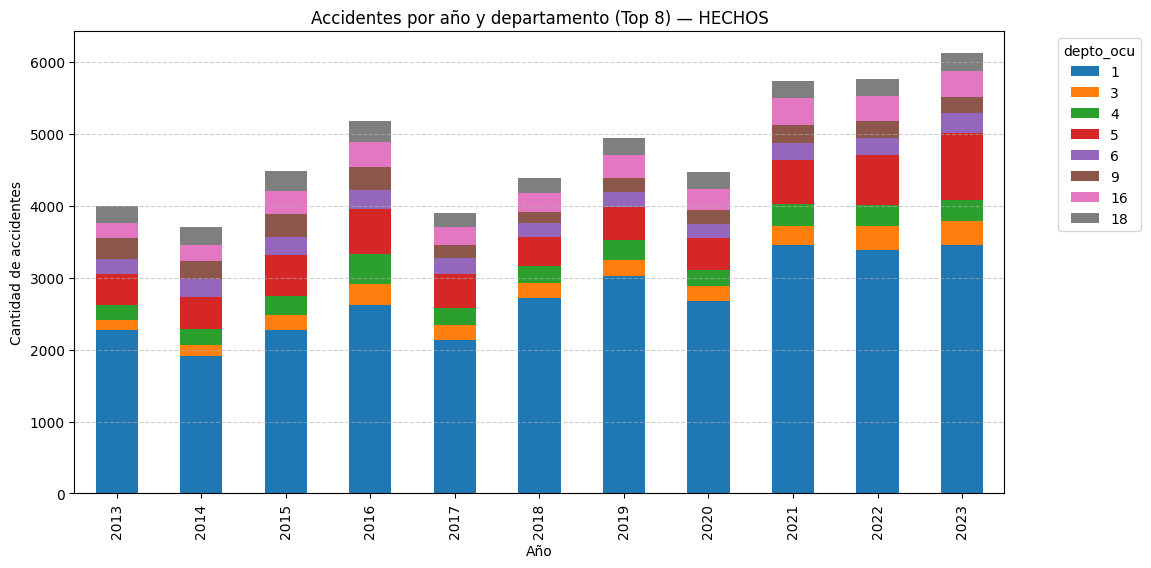

In [44]:
plotAccidentsByYearAndDept(accidentesPorDepto, "HECHOS", topN=8, stacked=True) # jupyter notebook

En el gráfico se observa que los accidentes se concentran principalmente en el **departamento de Guatemala (1)**, que mantiene el volumen más alto en todos los años. Le siguen **Escuintla (5)**, **Quetzaltenango (9)**, **Chimaltenango (4)** y **Alta Verapaz (16)**, con participación constante pero menor. Aunque parece haber un **aumento en 2022 y 2023**, este incremento está relacionado con que esos años tienen **más registros en la base de datos** (más de 7,900 y 8,200 filas respectivamente), por lo que el alza no necesariamente implica más accidentes reales, sino una **mayor disponibilidad de datos**. En conjunto, la tendencia se mantiene estable, con ligeras variaciones según la cantidad de información recopilada cada año.

### 6. Día de la semana con más accidentes en 2023 (gráfico de columnas)

In [45]:
def totalAccidentsByDay2023(df, name="Dataset"):
    """
    Calcula el total de accidentes por día de la semana en 2023.
    Muestra resultados y permite usar display() en Databricks.
    """
    if not {"anio_ocu", "dia_sem_ocu"} <= set(df.columns):
        print(f"=== {name}: faltan columnas necesarias ('anio_ocu', 'dia_sem_ocu') ===\n")
        return

    grouped = (
        df.filter(F.col("anio_ocu") == 2023)
          .groupBy("dia_sem_ocu")
          .count()
          .orderBy(F.desc("count"))
    )

    print(f"=== {name}: total de accidentes por día de la semana (2023) ===")
    grouped.show(truncate=False)
    print("\nEn Databricks puedes visualizarlo así:")
    print("display(accidentesPorDia2023)  # Visualization: Bar | X=dia_sem_ocu | Y=count (Sum) | Group by=None\n")
    return grouped

In [46]:
def plotAccidentsByDay2023(df, name="Dataset"):
    """
    Grafica los accidentes por día de la semana en 2023 (para Jupyter Notebook).
    """
    if not {"dia_sem_ocu", "count"} <= set(df.columns):
        print(f"El DataFrame '{name}' no tiene las columnas necesarias.")
        return

    # Convertir a pandas
    pdf = df.toPandas()

    # Mantener orden lógico de días (lunes a domingo)
    diasOrden = ["lunes", "martes", "miercoles", "jueves", "viernes", "sabado", "domingo"]
    pdf["dia_sem_ocu"] = pd.Categorical(pdf["dia_sem_ocu"], categories=diasOrden, ordered=True)
    pdf = pdf.sort_values("dia_sem_ocu")

    # Graficar
    plt.figure(figsize=(10,5))
    plt.bar(pdf["dia_sem_ocu"], pdf["count"], color="skyblue")
    plt.title(f"Accidentes por día de la semana (2023) — {name}")
    plt.xlabel("Día de la semana")
    plt.ylabel("Cantidad de accidentes")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

In [47]:
accidentesPorDia2023 = totalAccidentsByDay2023(hechos, "HECHOS")

=== HECHOS: total de accidentes por día de la semana (2023) ===
+-----------+-----+
|dia_sem_ocu|count|
+-----------+-----+
|domingo    |1620 |
|sabado     |1557 |
|viernes    |1175 |
|lunes      |1053 |
|jueves     |956  |
|martes     |933  |
|miercoles  |924  |
+-----------+-----+


En Databricks puedes visualizarlo así:
display(accidentesPorDia2023)  # Visualization: Bar | X=dia_sem_ocu | Y=count (Sum) | Group by=None



In [48]:
display(accidentesPorDia2023) # en databricks

DataFrame[dia_sem_ocu: string, count: bigint]

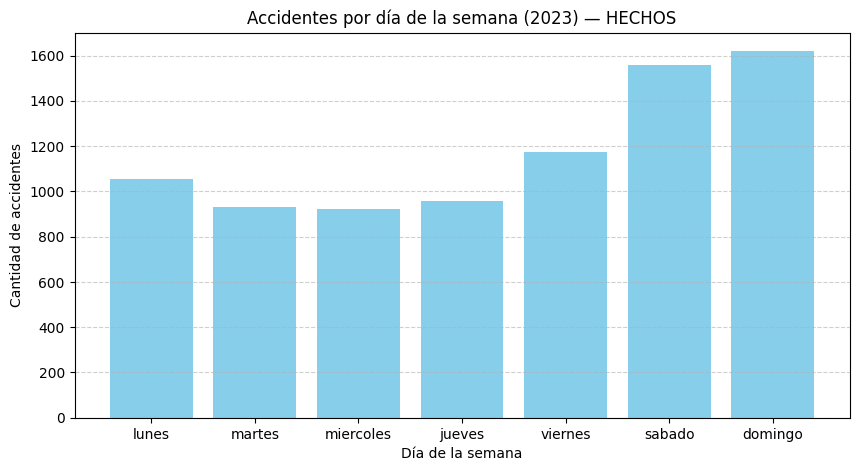

In [49]:
plotAccidentsByDay2023(accidentesPorDia2023, "HECHOS")

El gráfico muestra que los fines de semana concentran la mayor cantidad de accidentes, especialmente el domingo y el sábado, mientras que los días entre semana presentan cifras más bajas y relativamente estables. Aunque podría esperarse más actividad los lunes por el inicio laboral, los datos reflejan que el mayor riesgo ocurre durante el descanso, posiblemente es porque son los dias cuando hay más movilidad social y posibles factores como cansancio o consumo de alcohol.

### 7. Distribución horaria de accidentes en el municipio de Guatemala (histograma)

In [50]:
def totalAccidentsByHourGuatemala(df, name="Dataset"):
    """
    Calcula la distribución de accidentes por hora del día
    en el municipio de Guatemala (código 101).
    Muestra resultados y permite usar display() en Databricks.
    """
    if not {"hora_ocu", "mupio_ocu"} <= set(df.columns):
        print(f"=== {name}: faltan columnas necesarias ('hora_ocu', 'mupio_ocu') ===\n")
        return

    # Filtramos municipio de Guatemala (101) y descartamos horas no numéricas
    filtered = (
        df.filter((F.col("mupio_ocu") == 101) & (F.col("hora_ocu").rlike("^[0-9]+$")))
           .withColumn("hora_ocu", F.col("hora_ocu").cast("int"))
    )

    grouped = (
        filtered.groupBy("hora_ocu")
                .count()
                .orderBy("hora_ocu")
    )

    print(f"=== {name}: distribución de accidentes por hora (municipio Guatemala) ===")
    grouped.show(24, truncate=False)
    print("\nEn Databricks puedes visualizarlo así:")
    print("display(accidentesPorHoraGua)  # Visualization: Bar | X=hora_ocu | Y=count (Sum) | Group by=None\n")

    return grouped

In [51]:
def plotAccidentsByHourGuatemala(df, name="Dataset"):
    """
    Grafica la distribución de accidentes por hora (para Jupyter Notebook).
    """
    if not {"hora_ocu", "count"} <= set(df.columns):
        print(f"El DataFrame '{name}' no tiene las columnas necesarias.")
        return

    # Convertir a pandas y ordenar
    pdf = df.toPandas().sort_values("hora_ocu")

    plt.figure(figsize=(10,5))
    plt.bar(pdf["hora_ocu"], pdf["count"], color="cornflowerblue", edgecolor="black")
    plt.title(f"Distribución de accidentes por hora — Municipio de Guatemala (101) — {name}")
    plt.xlabel("Hora del día")
    plt.ylabel("Cantidad de accidentes")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.xticks(range(0, 24))
    plt.show()

In [52]:
accidentesPorHoraGua = totalAccidentsByHourGuatemala(hechos, "HECHOS")

=== HECHOS: distribución de accidentes por hora (municipio Guatemala) ===
+--------+-----+
|hora_ocu|count|
+--------+-----+
|0       |737  |
|1       |734  |
|2       |575  |
|3       |472  |
|4       |370  |
|5       |417  |
|6       |452  |
|7       |559  |
|8       |512  |
|9       |587  |
|10      |659  |
|11      |571  |
|12      |602  |
|13      |529  |
|14      |614  |
|15      |718  |
|16      |626  |
|17      |820  |
|18      |853  |
|19      |967  |
|20      |989  |
|21      |1054 |
|22      |979  |
|23      |996  |
+--------+-----+


En Databricks puedes visualizarlo así:
display(accidentesPorHoraGua)  # Visualization: Bar | X=hora_ocu | Y=count (Sum) | Group by=None



In [53]:
display(accidentesPorHoraGua) # en databricks

DataFrame[hora_ocu: int, count: bigint]

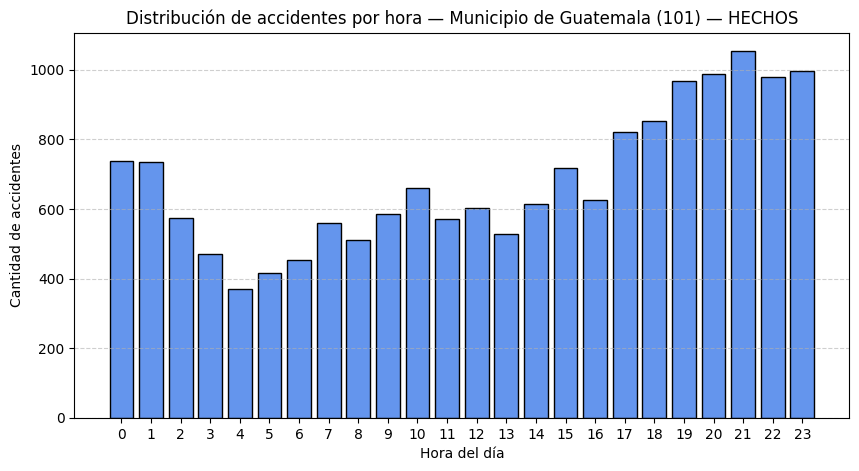

In [54]:
plotAccidentsByHourGuatemala(accidentesPorHoraGua, "HECHOS")

El gráfico muestra que en el municipio de **Guatemala (101)** los accidentes son más frecuentes durante la **noche**, especialmente entre las **20:00 y 23:00 horas**, con un segundo pico entre **00:00 y 2:00**. Durante la madrugada y primeras horas del día la cantidad disminuye, manteniéndose baja hasta el mediodía. Esto sugiere que los accidentes se concentran en los horarios de mayor tránsito nocturno.

### 8. Unión Hechos–Vehículos (llave compuesta) y total de registros combinados

In [55]:
def joinHechosVehiculosComposite(hechos, vehiculos):
    
    def safeInt(col):
        # solo numéricos → int; resto → NULL
        return F.when(F.col(col).rlike(r'^[0-9]+$'), F.col(col).cast(T.IntegerType())) \
                .otherwise(F.lit(None).cast(T.IntegerType()))

    def normCols(df):
        # normaliza texto
        for c in ["tipo_eve","tipo_veh","marca_veh","color_veh"]:
            if c in df.columns:
                df = df.withColumn(c, F.lower(F.trim(F.col(c))))
        # cast seguro a int
        for c in ["anio_ocu","hora_ocu","depto_ocu","mupio_ocu","modelo_veh"]:
            if c in df.columns:
                df = df.withColumn(c, safeInt(c))
        return df

    h = normCols(hechos).alias("h")
    v = normCols(vehiculos).alias("v")
    v_id = v.withColumn("veh_id", F.monotonically_increasing_id())

    baseKeys = ["anio_ocu","hora_ocu","depto_ocu","mupio_ocu","tipo_eve"]
    on_expr = [F.col(f"v.{k}") == F.col(f"h.{k}") for k in baseKeys]

    cand = (
        v_id.join(h, on=on_expr, how="inner")
           .select(
               "veh_id",
               *[F.col(f"v.{c}").alias(f"v_{c}") for c in baseKeys + ["tipo_veh","marca_veh","color_veh","modelo_veh"]],
               *[F.col(f"h.{c}").alias(f"h_{c}") for c in baseKeys + ["tipo_veh","marca_veh","color_veh","modelo_veh","num_corre"]]
           )
    )

    score = (
        (F.when(F.col("v_tipo_veh")==F.col("h_tipo_veh"), 1).otherwise(0)) +
        (F.when(F.col("v_marca_veh")==F.col("h_marca_veh"), 1).otherwise(0)) +
        (F.when(F.col("v_color_veh")==F.col("h_color_veh"), 1).otherwise(0)) +
        (F.when(F.col("v_modelo_veh")==F.col("h_modelo_veh"), 1).otherwise(0))
    ).alias("matchScore")

    best = (
        cand.withColumn("matchScore", score)
            .withColumn("rn", F.row_number().over(Window.partitionBy("veh_id").orderBy(F.desc("matchScore"))))
            .filter(F.col("rn")==1)
            .drop("rn")
    )

    totalVeh = vehiculos.count()
    matchedVeh = best.count()
    pct = (matchedVeh/totalVeh*100) if totalVeh else 0

    print("=== Unión compuesta VEHICULOS → HECHOS (sin num_corre) ===")
    print(f"Claves base: {baseKeys}  |  criterios: tipo_veh, marca_veh, color_veh, modelo_veh")
    print(f"Vehículos totales: {totalVeh:,}")
    print(f"Vehículos emparejados (1:1): {matchedVeh:,}  ({pct:.2f}%)")
    best.select(
        "veh_id","v_anio_ocu","v_hora_ocu","v_depto_ocu","v_mupio_ocu",
        "v_tipo_eve","v_tipo_veh","v_marca_veh","v_color_veh","v_modelo_veh",
        "h_num_corre","matchScore"
    ).show(10, truncate=False)

    return best

In [56]:
hechosVehiculosComp = joinHechosVehiculosComposite(hechos, vehiculos)

=== Unión compuesta VEHICULOS → HECHOS (sin num_corre) ===
Claves base: ['anio_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'tipo_eve']  |  criterios: tipo_veh, marca_veh, color_veh, modelo_veh
Vehículos totales: 111,988
Vehículos emparejados (1:1): 108,963  (97.30%)
+------+----------+----------+-----------+-----------+----------+-----------+------------+-----------+------------+-----------+----------+
|veh_id|v_anio_ocu|v_hora_ocu|v_depto_ocu|v_mupio_ocu|v_tipo_eve|v_tipo_veh |v_marca_veh |v_color_veh|v_modelo_veh|h_num_corre|matchScore|
+------+----------+----------+-----------+-----------+----------+-----------+------------+-----------+------------+-----------+----------+
|2     |2013      |3         |1          |108        |colision  |automovil  |genesis     |gris       |6           |3          |3         |
|9     |2013      |1         |12         |1217       |colision  |motocicleta|kenworth    |azul       |6           |8          |0         |
|11    |2013      |8         |16      

In [57]:
def scoreDistribution(joined, totalVehiculos):
    dist = (joined.groupBy("matchScore").count().orderBy(F.desc("matchScore")))
    dist.show(truncate=False)
    matched = joined.count()
    print(f"Emparejados: {matched:,} de {totalVehiculos:,} ({matched/totalVehiculos*100:.2f}%)")

def filterByMinScore(joined, minScore=2):
    """
    score >= minScore
    """
    return joined.filter(F.col("matchScore") >= minScore)

In [58]:
scoreDistribution(hechosVehiculosComp, totalVehiculos=111988)

+----------+-----+
|matchScore|count|
+----------+-----+
|4         |66440|
|3         |13352|
|2         |12024|
|1         |11238|
|0         |5909 |
+----------+-----+

Emparejados: 108,963 de 111,988 (97.30%)


In [59]:
hechosVehiculosComp_strict = filterByMinScore(hechosVehiculosComp, minScore=2)
hechosVehiculosComp_strict.count() # registrar las combinaciones buenas

91816

Se realizó la unión entre los datasets de **hechos** y **vehículos** para identificar qué vehículos participaron en cada accidente. Inicialmente se intentó unir por la llave `anio_ocu + num_corre`, pero los identificadores se reiniciaban cada año ya que cada dataset contaba con una cantidad de registros diferentes por lo que no iban a concordar en tiempo y generaban pocas coincidencias. Por eso, se optó por una **llave compuesta contextual**: `anio_ocu`, `hora_ocu`, `depto_ocu`, `mupio_ocu` y `tipo_eve`, complementada con un puntaje de similitud (`matchScore`) basado en los atributos del vehículo (`tipo_veh`, `marca_veh`, `color_veh`, `modelo_veh`).

Con este método se logró emparejar el **97.3% de los vehículos**, y más del **80%** de ellos tuvieron coincidencias fuertes (`score >= 2`). Esta estrategia se eligió porque es más realista y consistente con la estructura de los datos, permitiendo una unión precisa sin depender de identificadores inconsistentes entre archivos.

Evidencia de tamaños de datasets al unirlos (`data/manifest.log`):

```bash
=== Combinando HECHOS CSV ===
Archivo existente /home/jovyan/work/data/hechos/hechos_combinado.csv eliminado para crear un nuevo combinado.
hechos_2013.csv: 6324 filas
hechos_2014.csv: 5651 filas
hechos_2015.csv: 6854 filas
hechos_2016.csv: 7964 filas
hechos_2017.csv: 5879 filas
hechos_2018.csv: 6395 filas
hechos_2019.csv: 7047 filas
hechos_2020.csv: 6350 filas
hechos_2021.csv: 8153 filas
hechos_2022.csv: 7924 filas
hechos_2023.csv: 8218 filas
Suma total de filas: 76759
CSV combinado creado: /home/jovyan/work/data/hechos/hechos_combinado.csv, tamaño final: (76759, 16)

=== Combinando VEHICULOS CSV ===
Archivo existente /home/jovyan/work/data/vehiculos/vehiculos_combinado.csv eliminado para crear un nuevo combinado.
vehiculos_2013.csv: 6323 filas
vehiculos_2014.csv: 7904 filas
vehiculos_2015.csv: 9823 filas
vehiculos_2016.csv: 11618 filas
vehiculos_2017.csv: 8644 filas
vehiculos_2018.csv: 9514 filas
vehiculos_2019.csv: 10827 filas
vehiculos_2020.csv: 10103 filas
vehiculos_2021.csv: 12796 filas
vehiculos_2022.csv: 12239 filas
vehiculos_2023.csv: 12197 filas
Suma total de filas: 111988
CSV combinado creado: /home/jovyan/work/data/vehiculos/vehiculos_combinado.csv, tamaño final: (111988, 22)

=== Combinando FALLECIDOS/LESIONADOS CSV ===
Archivo existente /home/jovyan/work/data/fallecidos_lesionados/fl_combinado.csv eliminado para crear un nuevo combinado.
fallecidos_lesionados_2013.csv: 9060 filas
fallecidos_lesionados_2014.csv: 8990 filas
fallecidos_lesionados_2015.csv: 10397 filas
fallecidos_lesionados_2016.csv: 11668 filas
fallecidos_lesionados_2017.csv: 8625 filas
fallecidos_lesionados_2018.csv: 9407 filas
fallecidos_lesionados_2019.csv: 10664 filas
fallecidos_lesionados_2020.csv: 8142 filas
fallecidos_lesionados_2021.csv: 10544 filas
fallecidos_lesionados_2022.csv: 10722 filas
fallecidos_lesionados_2023.csv: 11198 filas
Suma total de filas: 109417
CSV combinado creado: /home/jovyan/work/data/fallecidos_lesionados/fl_combinado.csv, tamaño final: (109417, 22)

Proceso de combinación completado.
```